# Análises PIBIC-EM – Visualizações (Jamovi → Colab)

Este notebook tem como objetivo gerar visualizações gráficas a partir da base
utilizada no Jamovi, para documentar e ilustrar os resultados já obtidos
(nível de produção acadêmica, tipo de instituição e participação em chamadas).

- Autor: Tiago Ribeiro dos Anjos
- Projeto: PIBIC-EM – Perfil dos pesquisadores e instituições
- Ambiente: Google Colab


## 1. Importar bibliotecas

Execute esta célula sempre que abrir o notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo básico dos gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Montar Google Drive

CSV exportado do Jamovi.

In [3]:
# Execute esta célula apenas no Google Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive montado com sucesso.")
except ImportError:
    print("Google Colab não detectado. Pule esta etapa se estiver em outro ambiente.")


Mounted at /content/drive
Drive montado com sucesso.


## 3. Carregar a base exportada do Jamovi

- No Jamovi, use **Data → Export → CSV**.
- Inclua pelo menos as colunas:
  - `tipo_ies_corrigido`
  - `nivel_producao_3grupos`
  - `num_chamadas_participou`

Ajuste o caminho abaixo para o local onde o arquivo foi salvo.

In [4]:
# Ajuste este caminho para o local correto do seu arquivo CSV
caminho_arquivo = (
    "/content/drive/MyDrive/DOUTORADO UFSCar/"
    "Doutorado Sanduíche no Exterior - PDSE/University of Toronto/"
    "Chamadas Públicas ICJ-CNPq/PIBIC_EM_ANALISE_JAMOVI/"
    "04_Resultados_Exportados/"
    "2025_11_14_tipos_de_instituicao_producao_academica_participacao_PIBIC-EM.csv"
)
df = pd.read_csv(caminho_arquivo)
print("Dimensões da base:", df.shape)
df.head()


Dimensões da base: (541, 42)


,id_pesq,pesquisador_padronizado,genero,grande_area,area_macro,area_sub,grande_area_freq,grande_area_score_sum,area,area_freq,...,ch_2016,ch_2018,ch_2020,ch_2022,ch_2024,oa_author_id,ano_chamada,periodo_vigencia,periodo_vigencia_anos,anos_vigencia
0,1,João Paulo Sinnecker,Masculino,Physics,Exatas,condensed matter physics,118.0,25.461093,Condensed matter physics,97.0,...,1,1,1,0,0,https://openalex.org/A5041162909,2014 (PIBIC-EM 2014-2016); 2016 (CNPq 07/2016)...,2014-2016; 2016-2018; 2018-2020; 2020-2021,2014-2021,7
1,2,Andre Massafferri Rodrigues,Masculino,Physics,Exatas,particle physics,88.0,58.446629,Particle physics,63.0,...,0,0,0,1,1,https://openalex.org/A5034635771,2022 (CNPq 35/2022); 2024 (CNPq 07/2024),2022-2024; 2024-2027,2022-2027,5
2,3,Maria de Lourdes Aguiar Oliveira,Feminino,Medicine,Multidisciplinar,virology,38.0,15.885419,Virology,30.0,...,0,0,0,0,1,https://openalex.org/A5057102618,2024 (CNPq 07/2024),2024-2027,2024-2027,3
3,4,Rodrigo Guerino Stabeli,Masculino,Biology,Exatas,biochemistry,117.0,49.397802,Biochemistry,90.0,...,1,0,0,0,0,https://openalex.org/A5054916263,2014 (PIBIC-EM 2014-2016); 2016 (CNPq 07/2016),2014-2016; 2016-2018,2014-2018,4
4,5,Talita Mazon,Feminino,Materials science,Multidisciplinar,nanotechnology,49.0,30.391361,Nanotechnology,33.0,...,1,0,0,0,0,https://openalex.org/A5070791259,2014 (PIBIC-EM 2014-2016),2014-2016,2014-2016,2


## 4. Checagem rápida das variáveis

Verifique se as colunas possuem os nomes esperados e se não há problemas óbvios.

In [5]:
df.info()

print("\nFrequências de tipo_ies_corrigido:")
print(df["tipo_ies_corrigido"].value_counts(dropna=False))

print("\nFrequências de nivel_producao_3grupos:")
print(df["nivel_producao_3grupos"].value_counts(dropna=False))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_pesq                   541 non-null    int64  
 1   pesquisador_padronizado   541 non-null    object 
 2   genero                    541 non-null    object 
 3   grande_area               541 non-null    object 
 4   area_macro                541 non-null    object 
 5   area_sub                  539 non-null    object 
 6   grande_area_freq          528 non-null    float64
 7   grande_area_score_sum     528 non-null    float64
 8   area                      541 non-null    object 
 9   area_freq                 528 non-null    float64
 10  area_score_sum            528 non-null    float64
 11  h_index                   528 non-null    float64
 12  nivel_producao            541 non-null    object 
 13  nivel_producao_3grupos    541 non-null    object 
 14  i10_index 

## 5. Gráfico 1 – Distribuição por tipo de instituição

Gráfico de contagem simples para mostrar quantos pesquisadores há em cada
categoria de `tipo_ies_corrigido`.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import pandas as pd
from IPython.display import display, Image

# ---------------------------------------------------------
# Estilo APA
# ---------------------------------------------------------
def estilo_apa():
    mpl.rcParams.update({
        "font.family": "DejaVu Serif",
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 300
    })

# ---------------------------------------------------------
# Mapeamentos PT/EN
# ---------------------------------------------------------
map_pt = {
    "publica_federal": "Pública Federal",
    "privada": "Privada",
    "publica_estadual": "Pública Estadual",
    "instituto_de_pesquisa": "Instituto de Pesquisa",
    "publica_municipal_outras": "Pública Municipal / Outras"
}

map_en = {
    "publica_federal": "Federal University",
    "privada": "Private Institution",
    "publica_estadual": "State University",
    "instituto_de_pesquisa": "Research Institute",
    "publica_municipal_outras": "Municipal / Other Public"
}

df["tipo_ies_label_pt"] = df["tipo_ies_corrigido"].map(map_pt)
df["tipo_ies_label_en"] = df["tipo_ies_corrigido"].map(map_en)

# ordem pela frequência real
ord_pt = df["tipo_ies_label_pt"].value_counts().index
ord_en = df["tipo_ies_label_en"].value_counts().index

# paletas
cinza = ["0.2", "0.5", "0.8", "0.6", "0.4"]
colorida = sns.color_palette("colorblind", 5)

# ---------------------------------------------------------
# Função geradora
# ---------------------------------------------------------
def gerar_grafico1(idioma="pt", palette="gray"):

    estilo_apa()
    fig, ax = plt.subplots(figsize=(9, 7), dpi=300)

    if idioma == "pt":
        data_col = "tipo_ies_label_pt"
        ordem = ord_pt
        xlabel = "Tipo de instituição"
        ylabel = "Número de pesquisadores"
    else:
        data_col = "tipo_ies_label_en"
        ordem = ord_en
        xlabel = "Type of Institution"
        ylabel = "Number of Researchers"

    cores = cinza if palette == "gray" else colorida

    sns.countplot(
        data=df,
        x=data_col,
        order=ordem,
        palette=cores,
        edgecolor="0.2",
        ax=ax
    )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

    return fig

# ---------------------------------------------------------
# Gerar todas as imagens
# ---------------------------------------------------------
arquivos = {
    "PT_cinza": ("fig1_PT_cinza.png", "pt", "gray"),
    "PT_color": ("fig1_PT_color.png", "pt", "color"),
    "EN_cinza": ("fig1_EN_grayscale.png", "en", "gray"),
    "EN_color": ("fig1_EN_color.png", "en", "color"),
}

for nome, (arquivo, idioma, paleta) in arquivos.items():
    print(f"Gerando figura: {arquivo}")
    fig = gerar_grafico1(idioma=idioma, palette=paleta)
    fig.savefig(arquivo, dpi=600, bbox_inches="tight")
    plt.close(fig)

print("\n✔️ Todas as 4 versões do Gráfico 1 foram geradas com sucesso!\n")

for nome, (arquivo, _, _) in arquivos.items():
    display(Image(filename=arquivo, width=350))





Output hidden; open in https://colab.research.google.com to view.

## 6. Gráfico 2 – Barras empilhadas: tipo de instituição × nível de produção

Este gráfico mostra a distribuição do tipo de instituição dentro de cada
categoria de nível de produção acadêmica.


Gerando Gráfico 2 totalmente corrigido...

 -> fig2_PT_cinza_corrigido.png


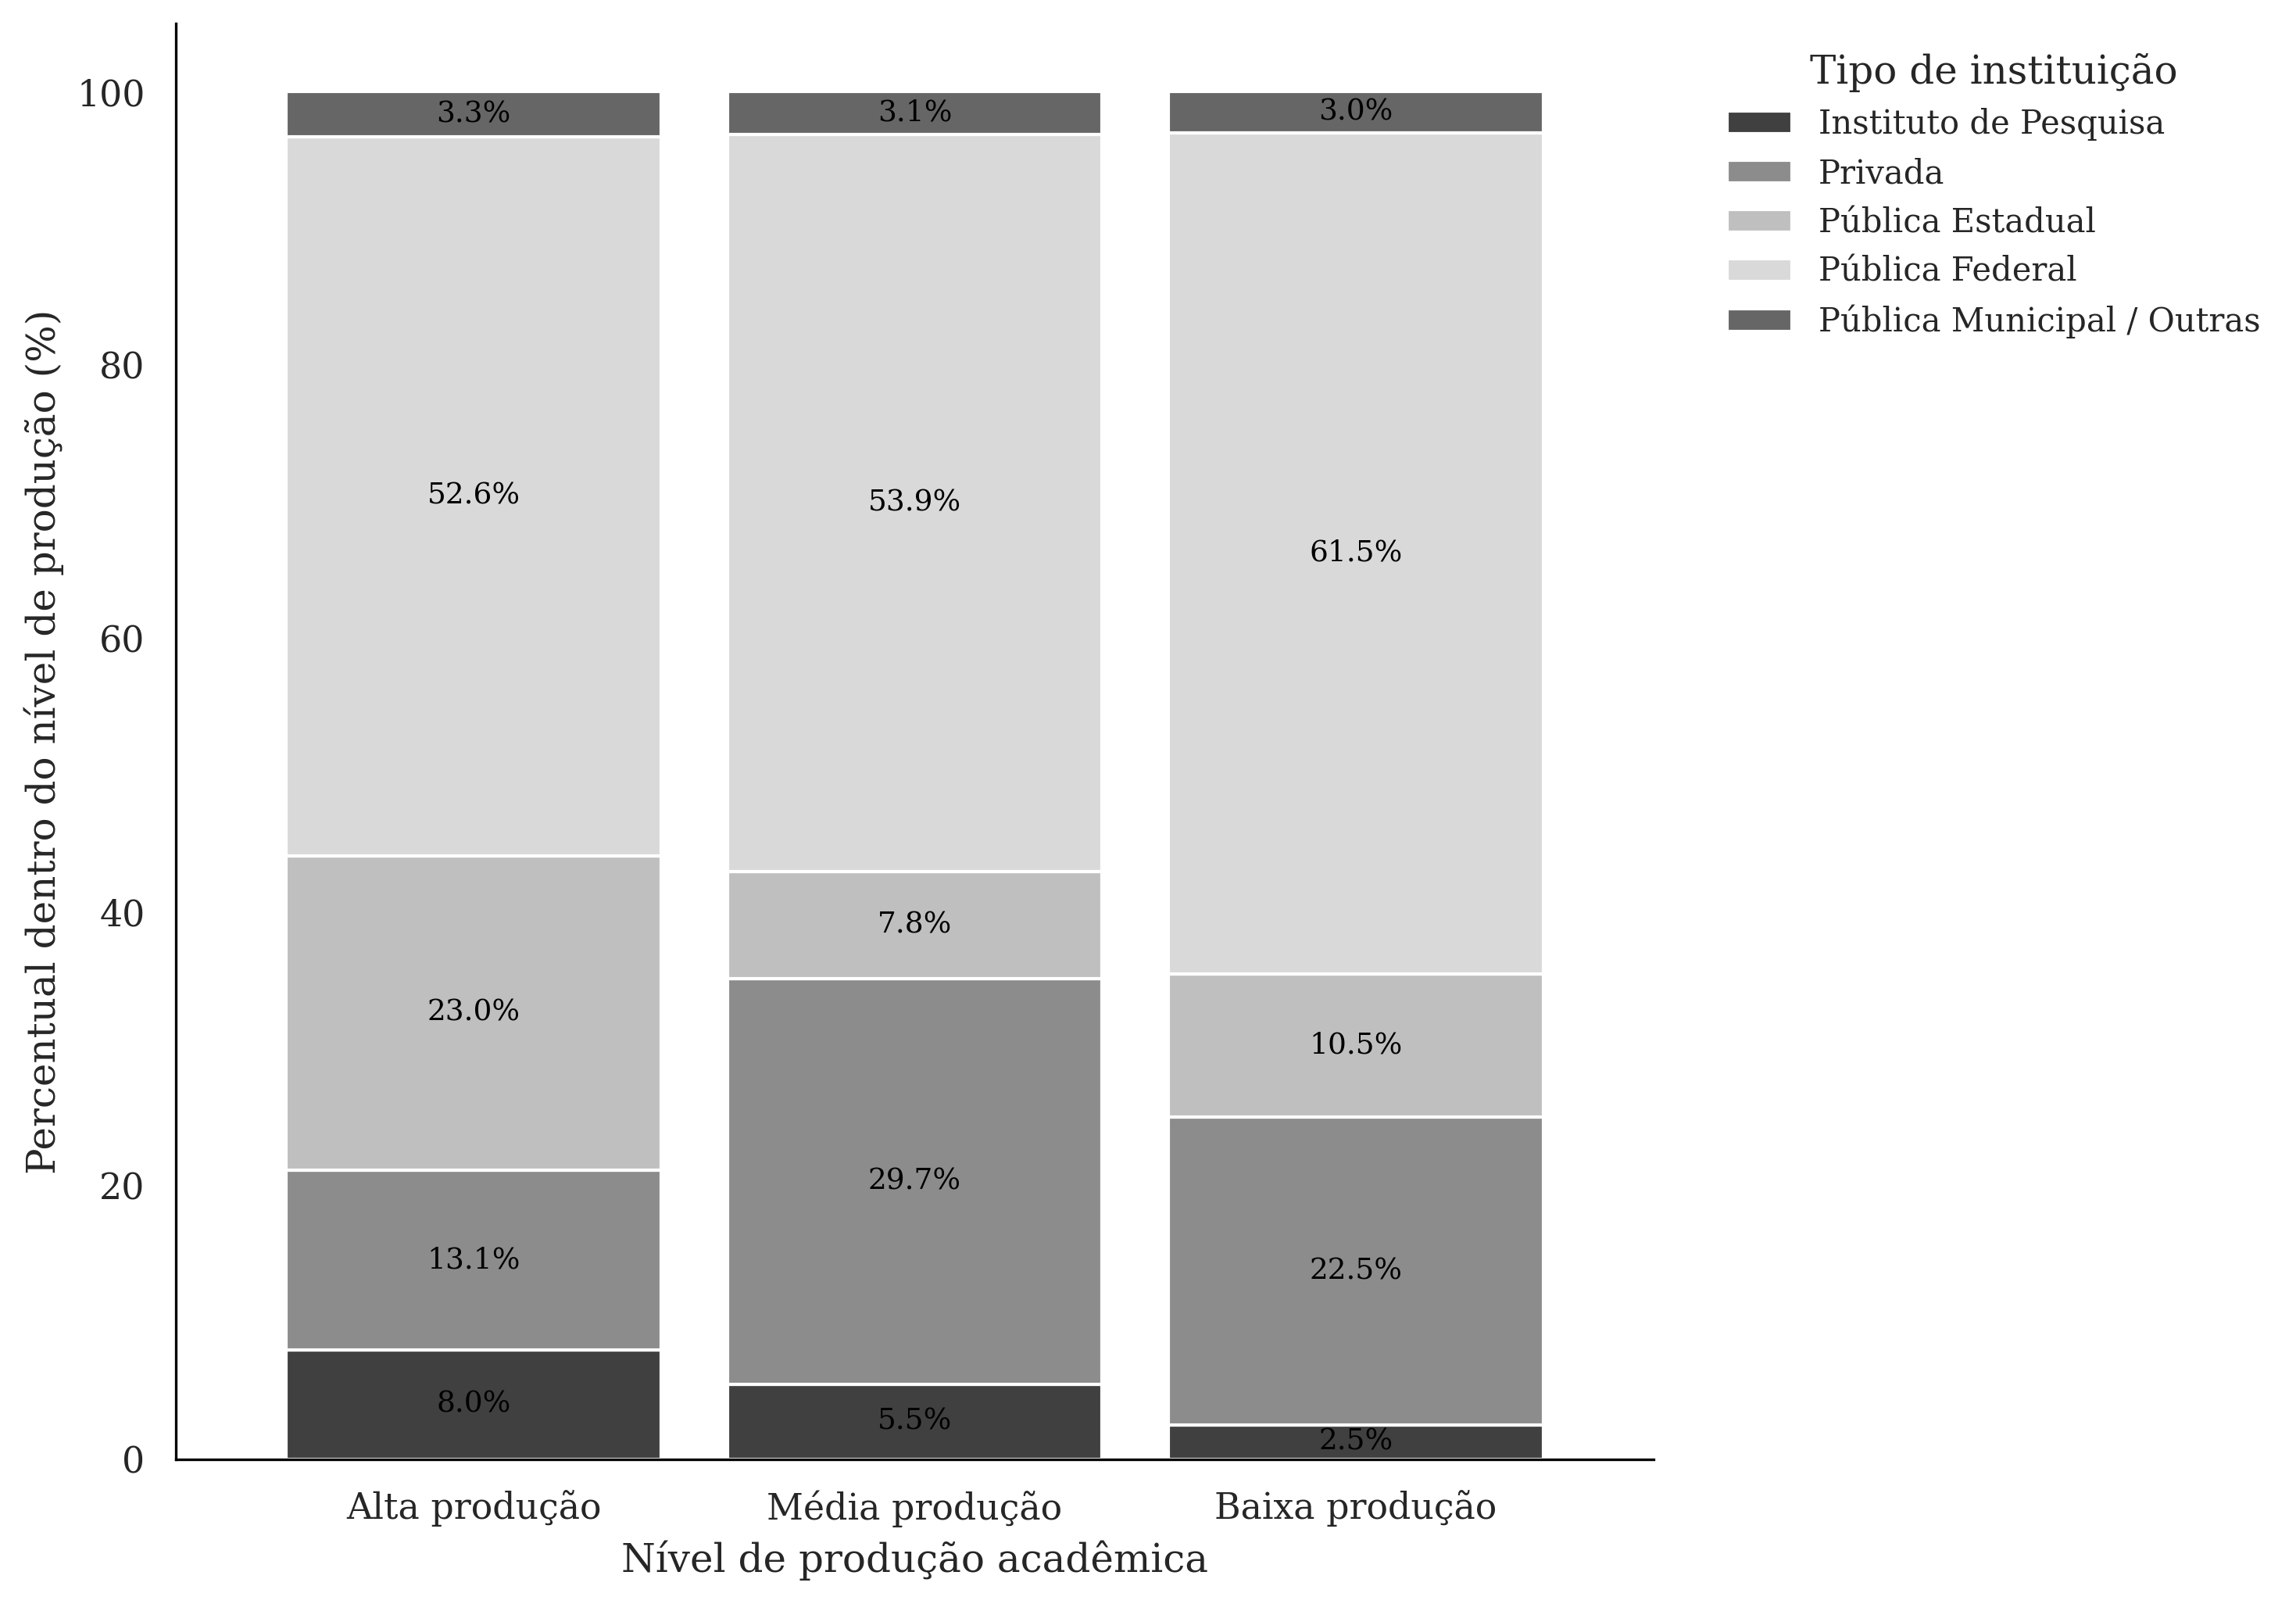

 -> fig2_PT_color_corrigido.png


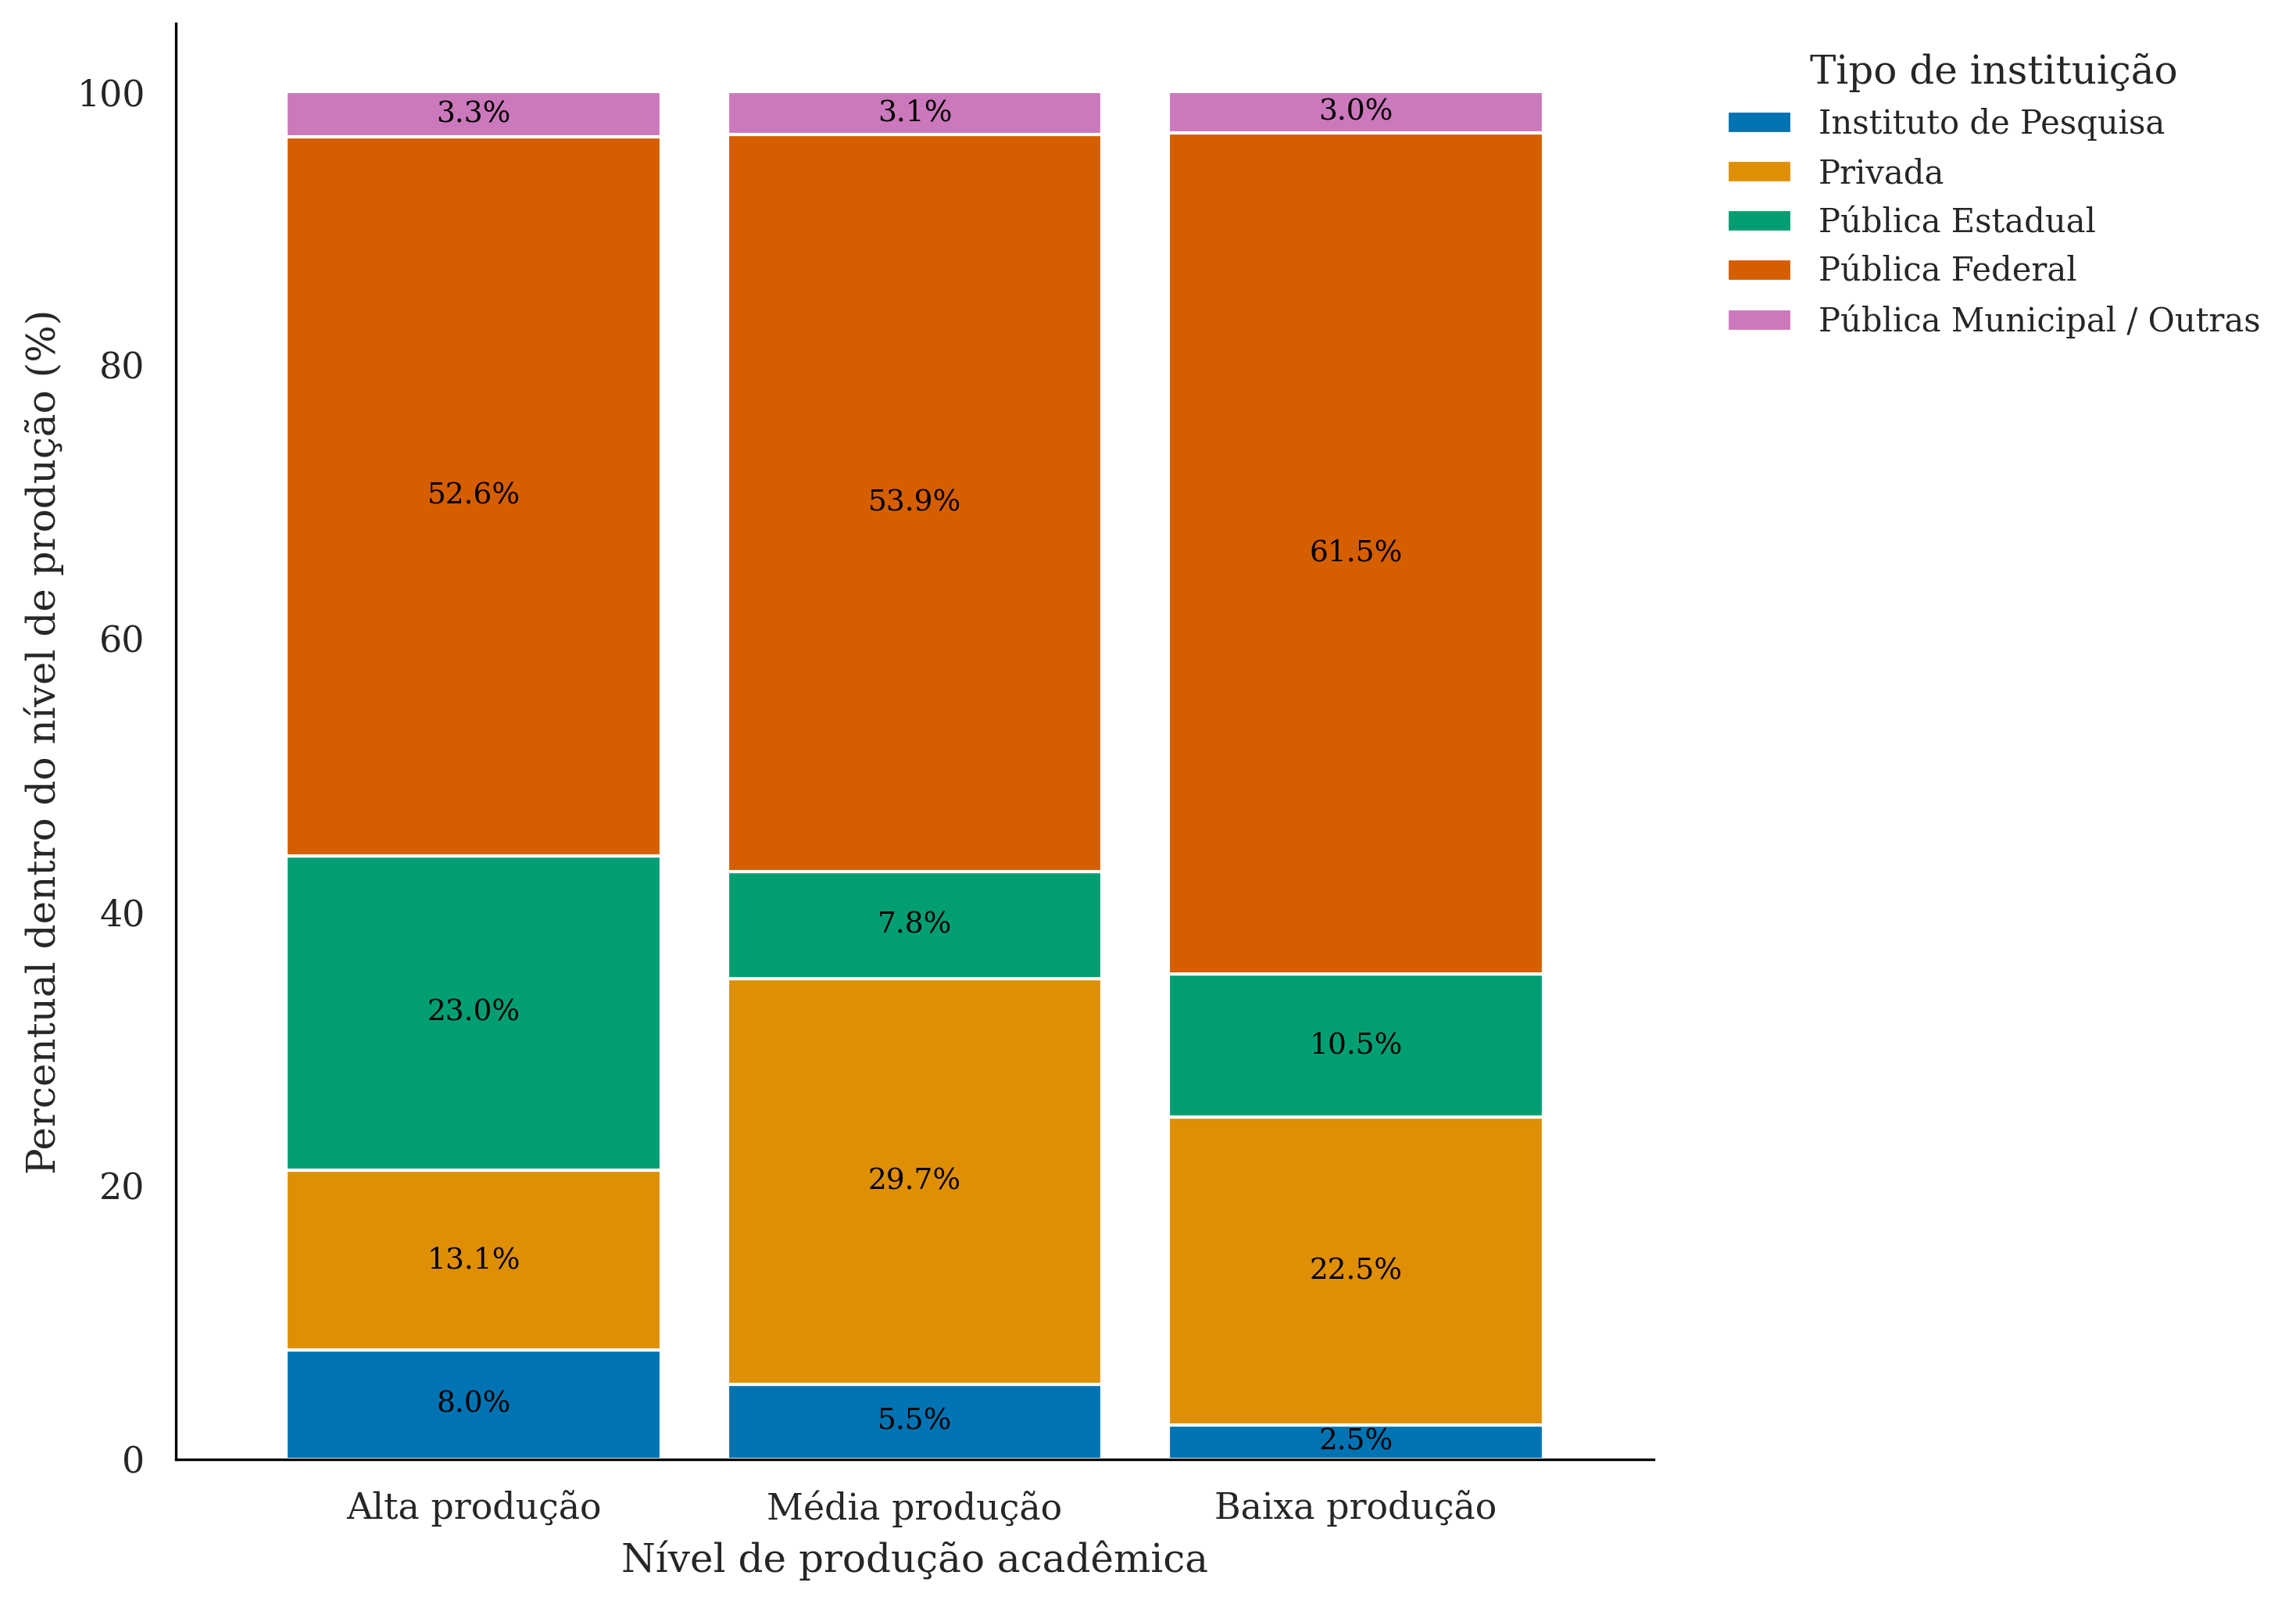

 -> fig2_EN_gray_corrigido.png


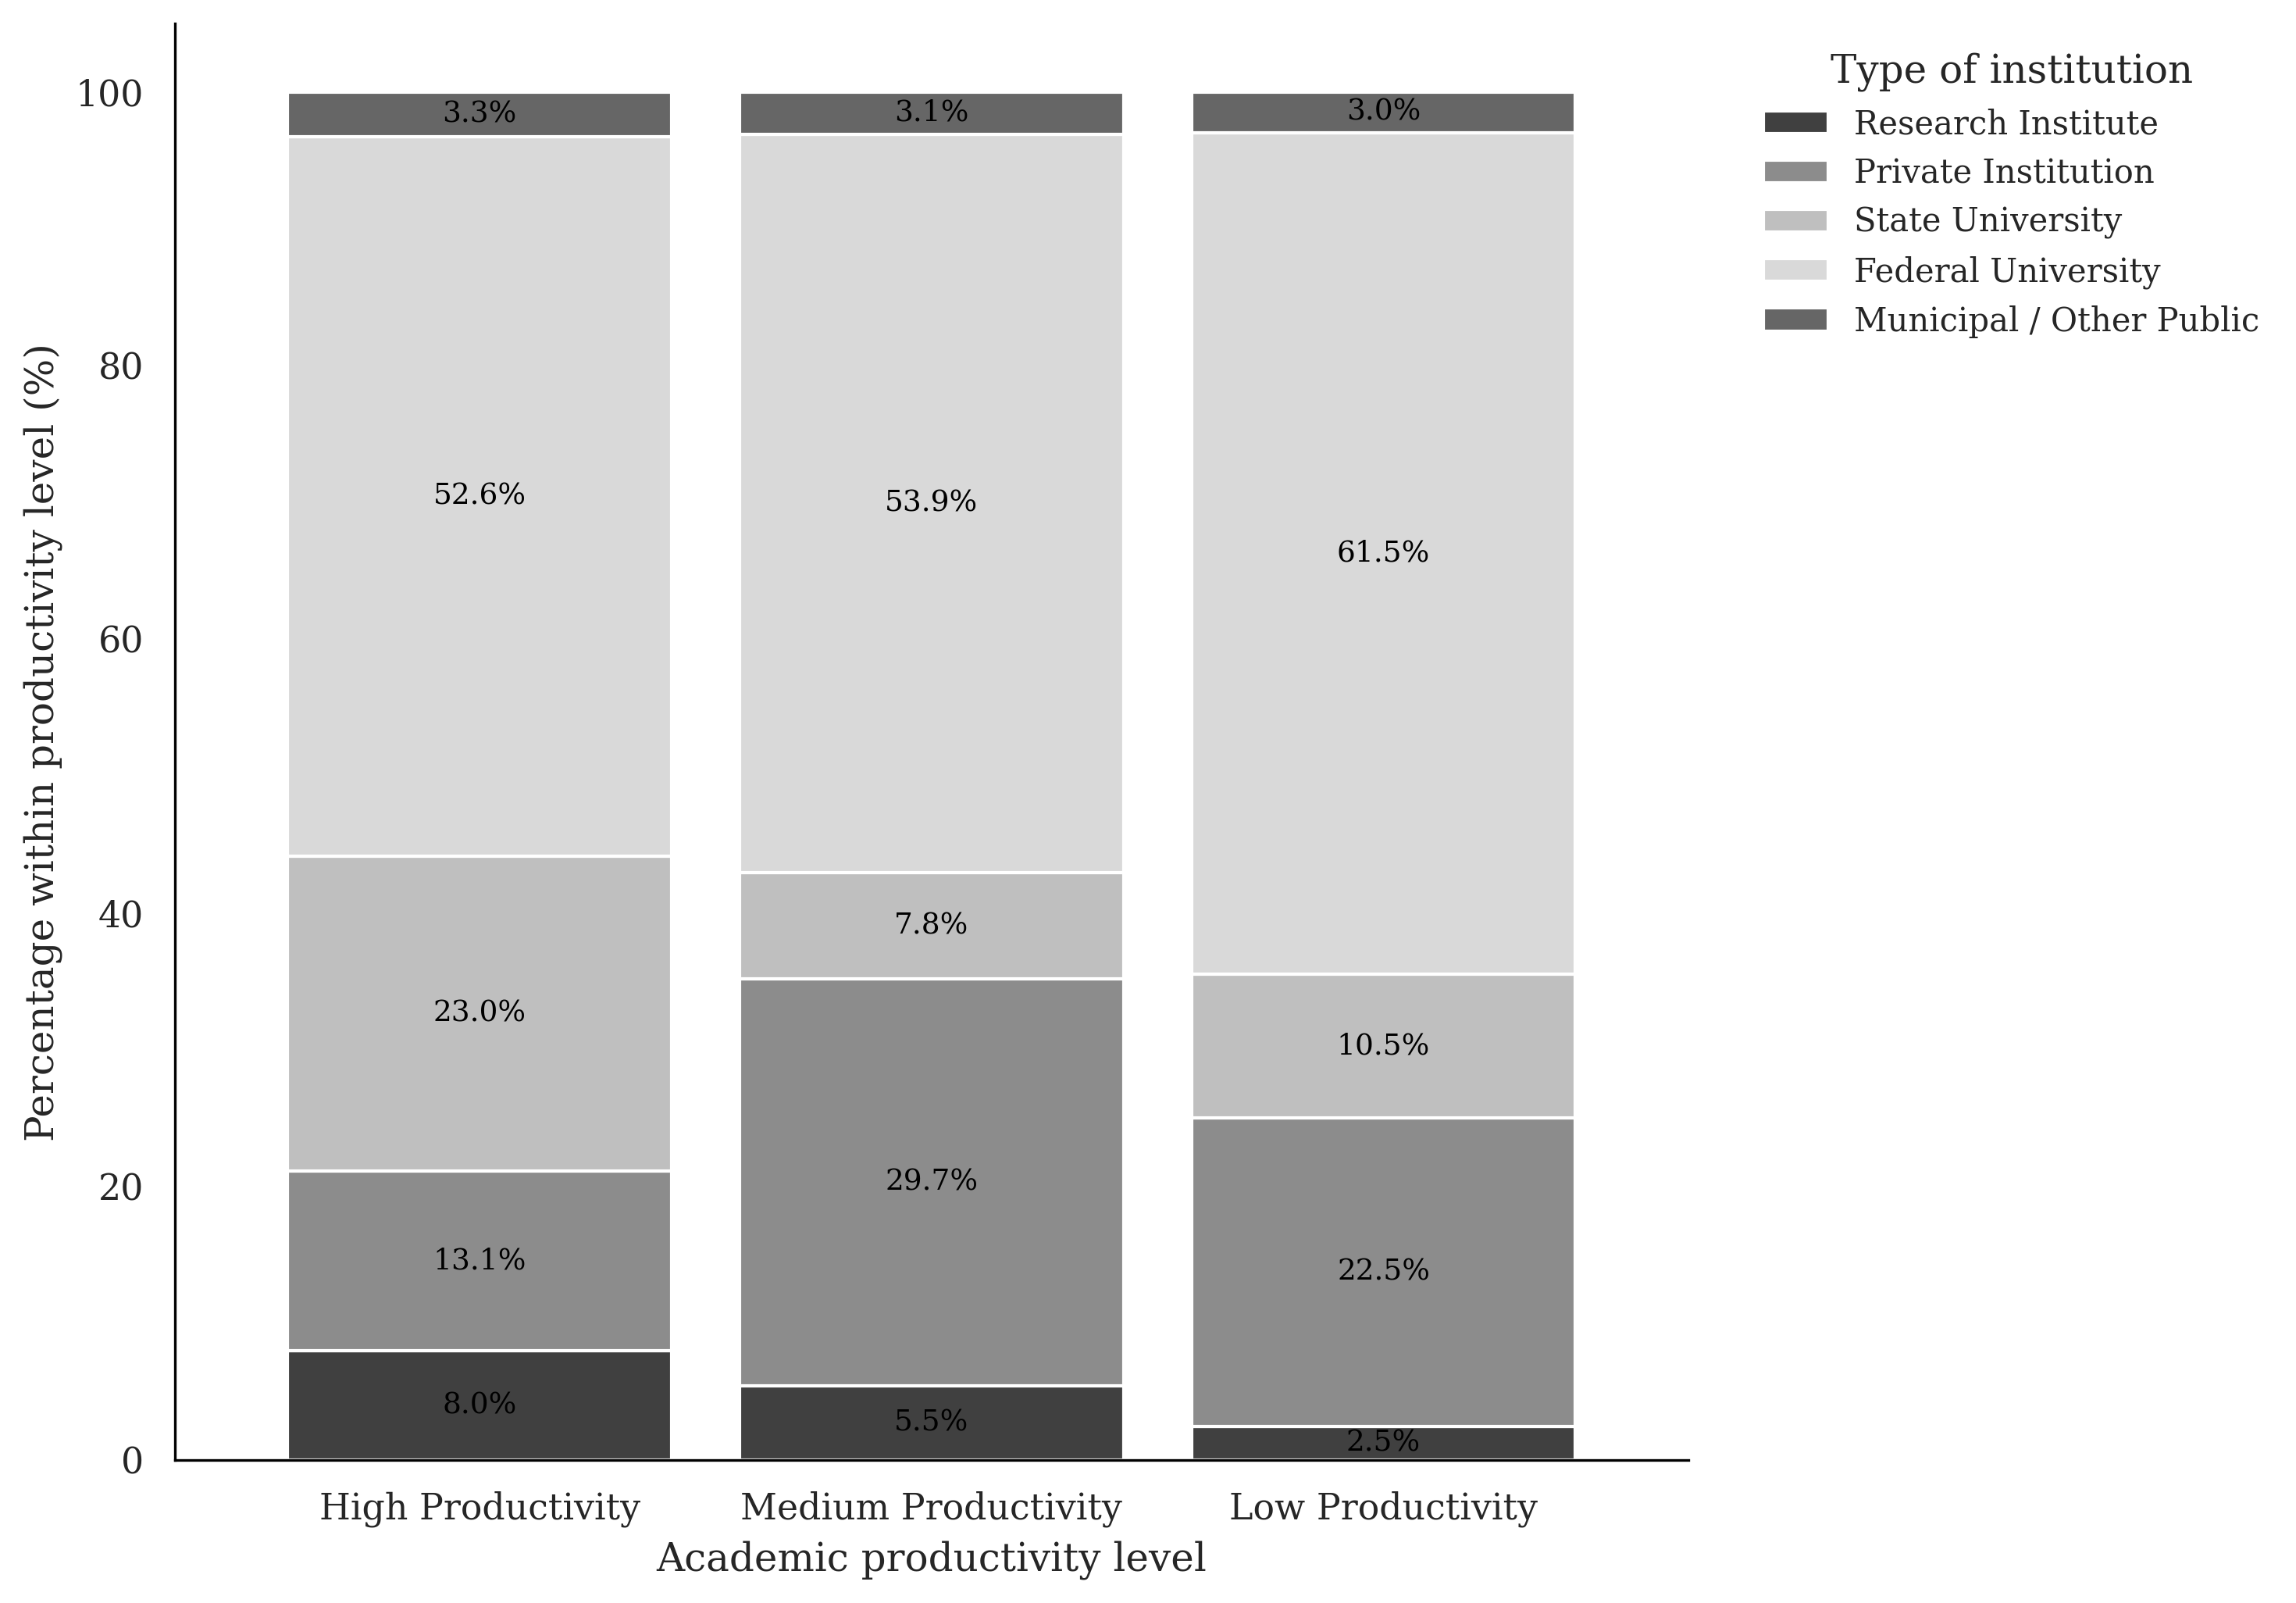

 -> fig2_EN_color_corrigido.png


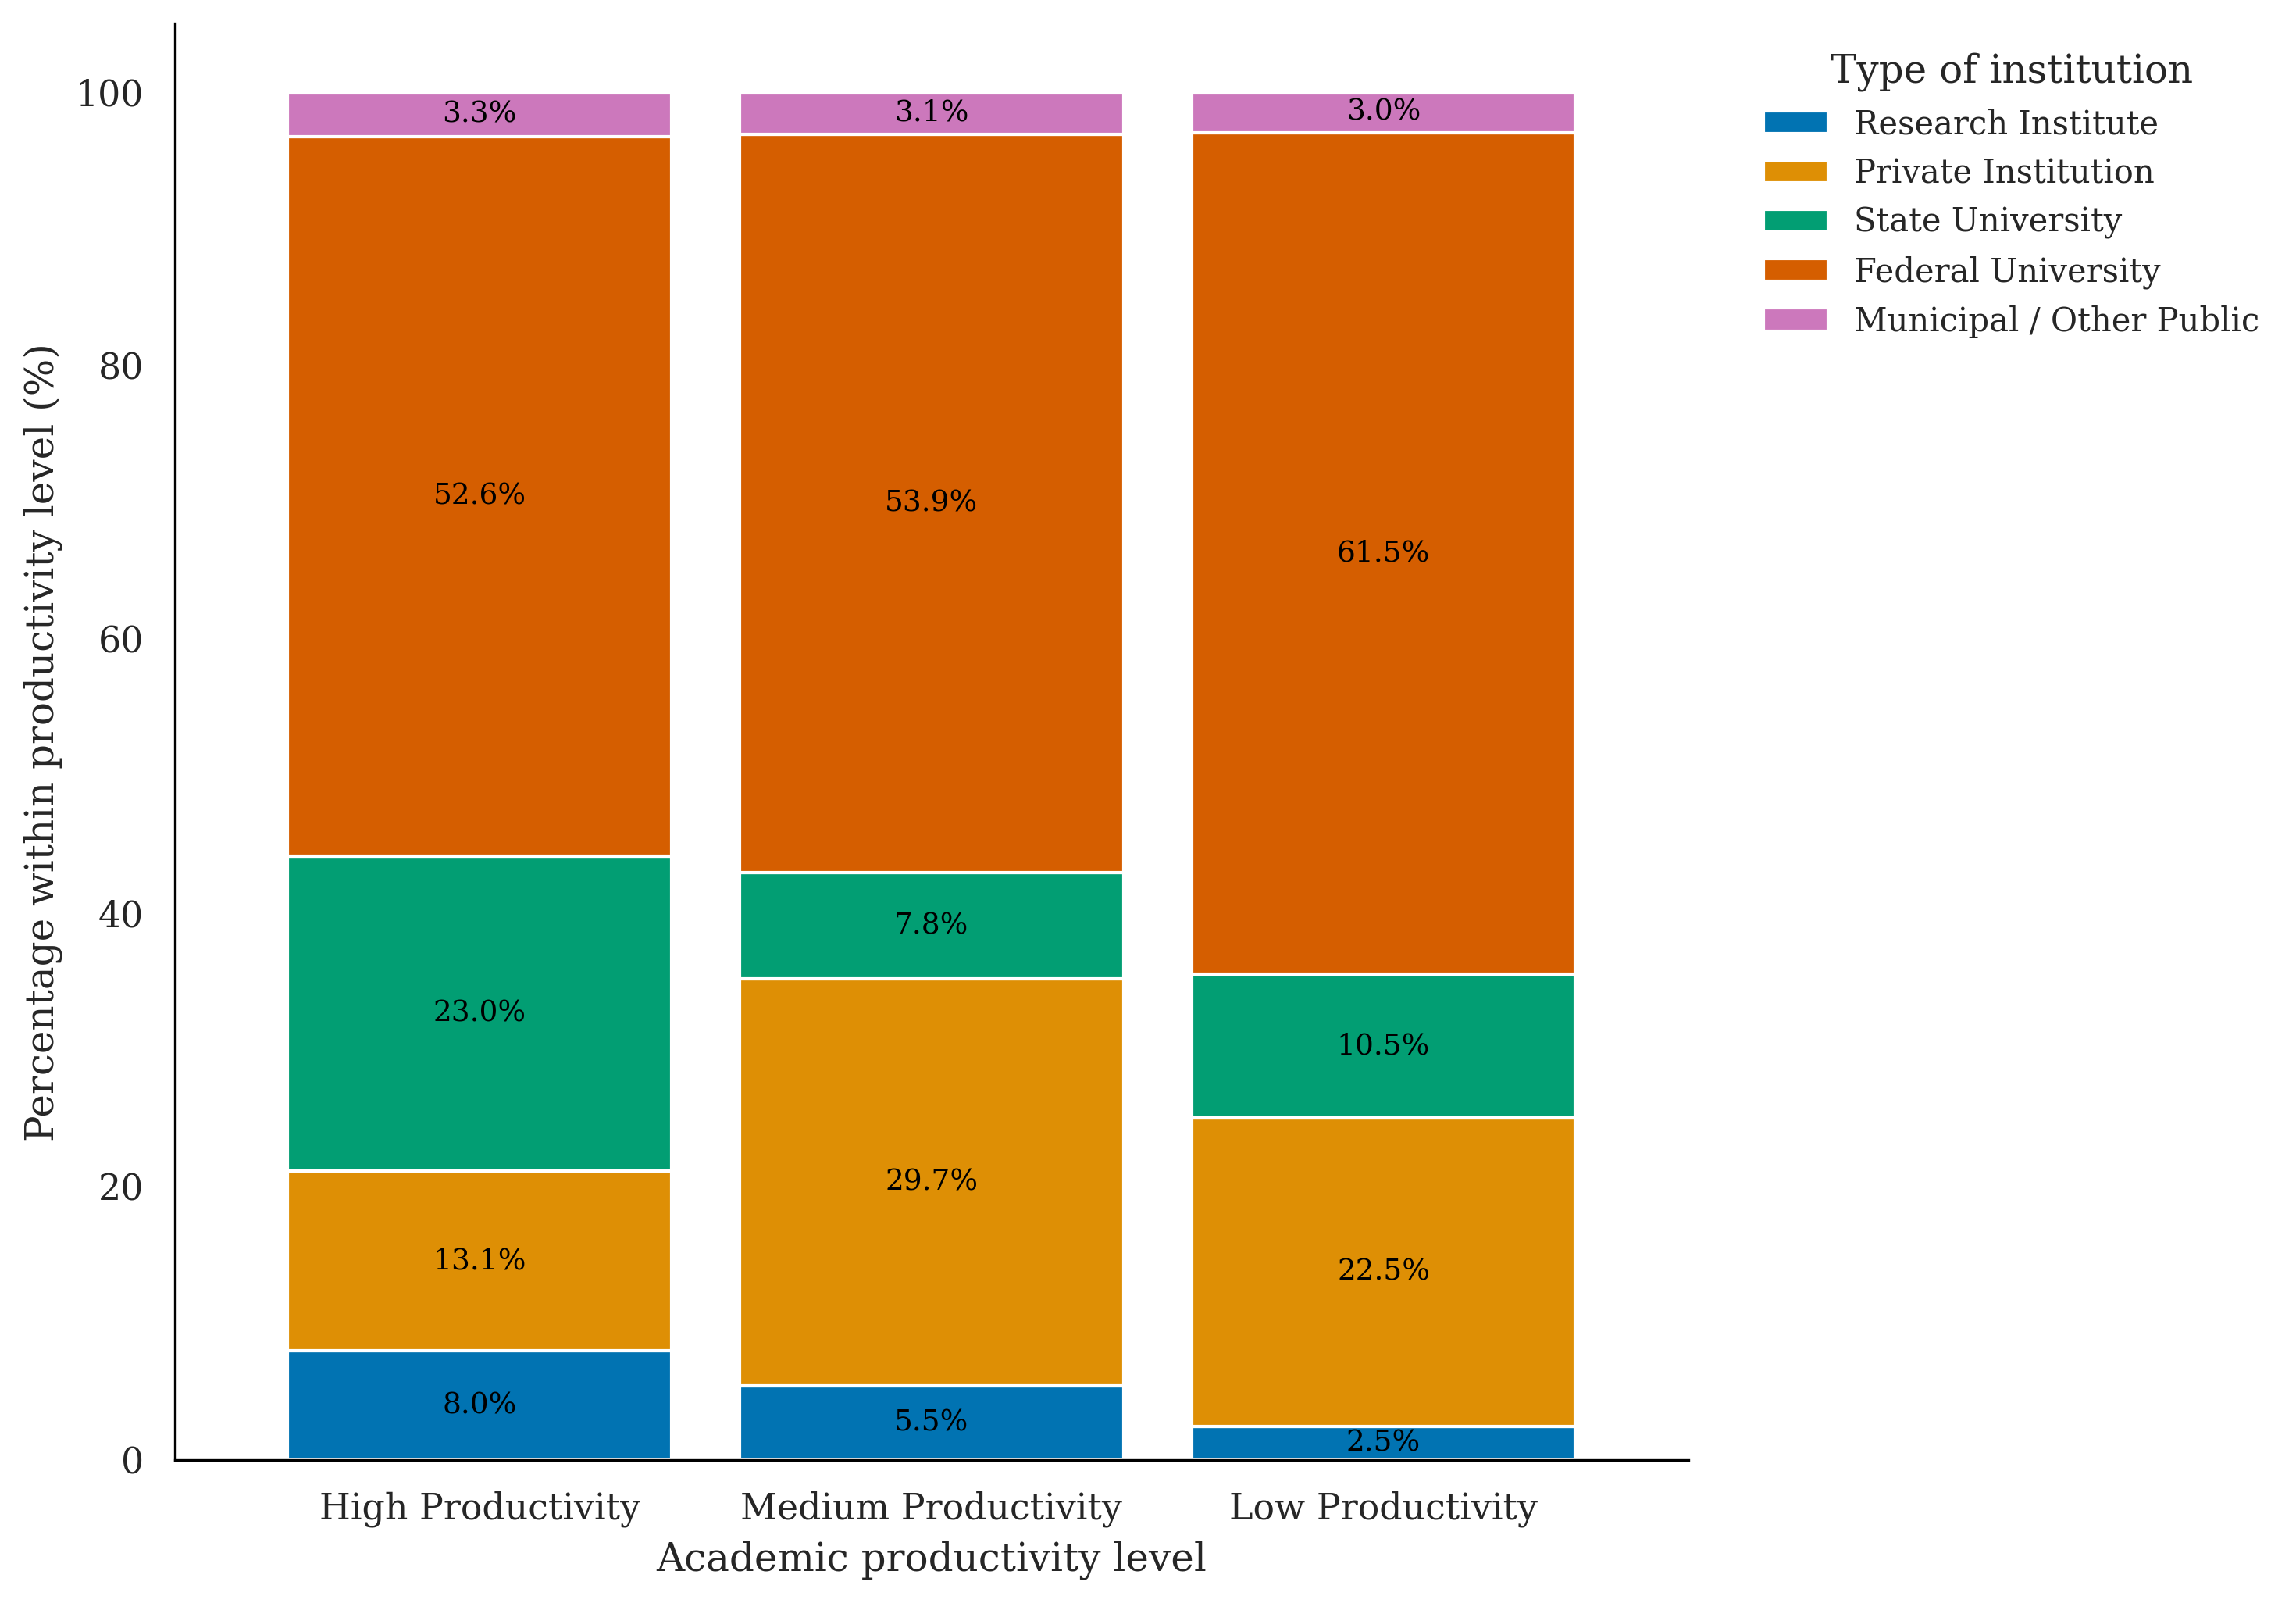


✔️ Todas as versões do Gráfico 2 foram geradas com sucesso!



In [17]:
# ===============================================================
# GRÁFICO 2 CORRIGIDO — Distribuição por nível de produção
# PT / EN × cinza / colorido
# Rótulos 100% centralizados e eixo X horizontal
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# -------------------------------------------------------
# Estilo APA
# -------------------------------------------------------
def estilo_apa():
    mpl.rcParams.update({
        "font.family": "DejaVu Serif",
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
        "figure.dpi": 300
    })

# -------------------------------------------------------
# Função corrigida para gerar o gráfico
# -------------------------------------------------------
def grafico2_corrigido(ct_table, idioma="pt", palette="gray"):
    estilo_apa()
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

    # Paletas
    tons_cinza = ["0.25", "0.55", "0.75", "0.85", "0.40"]
    cores = tons_cinza[:len(ct_table)] if palette == "gray" else sns.color_palette("colorblind", len(ct_table))

    # Plot stacked bars
    ct_table.T.plot(
        kind="bar",
        stacked=True,
        color=cores,
        ax=ax,
        width=0.85
    )

    # ----------------------------------------------------------
    # RÓTULOS NO CENTRO DE CADA SEÇÃO
    # ----------------------------------------------------------
    for col_idx, col in enumerate(ct_table.columns):
        cumulative = 0
        for row_idx, (inst, valor) in enumerate(ct_table[col].items()):

            if valor > 0:
                ax.text(
                    x=col_idx,
                    y=cumulative + valor / 2,
                    s=f"{valor:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += valor

    # ----------------------------------------------------------
    # Textos PT / EN
    # ----------------------------------------------------------
    if idioma == "pt":
        ax.set_xlabel("Nível de produção acadêmica")
        ax.set_ylabel("Percentual dentro do nível de produção (%)")
        legenda = "Tipo de instituição"
    else:
        ax.set_xlabel("Academic productivity level")
        ax.set_ylabel("Percentage within productivity level (%)")
        legenda = "Type of institution"

    # Legenda APA
    ax.legend(
        title=legenda,
        frameon=False,
        bbox_to_anchor=(1.03, 1),
        loc="upper left"
    )

    # ----------------------------------------------------------
    # EIXO X HORIZONTAL
    # ----------------------------------------------------------
    ax.set_xticklabels(ct_table.columns, rotation=0)

    plt.tight_layout()
    plt.show()
    return fig


# ===============================================================
# Gerar automaticamente as 4 versões
# ===============================================================

arquivos = {
    "PT_gray": ("fig2_PT_cinza_corrigido.png", ct_pt, "pt", "gray"),
    "PT_color": ("fig2_PT_color_corrigido.png", ct_pt, "pt", "color"),
    "EN_gray": ("fig2_EN_gray_corrigido.png", ct_en, "en", "gray"),
    "EN_color": ("fig2_EN_color_corrigido.png", ct_en, "en", "color"),
}

print("\nGerando Gráfico 2 totalmente corrigido...\n")

for nome, (arquivo, tabela, idioma, paleta) in arquivos.items():
    print(f" -> {arquivo}")
    fig = grafico2_corrigido(tabela, idioma=idioma, palette=paleta)
    fig.savefig(arquivo, dpi=600, bbox_inches="tight")
    plt.close(fig)

print("\n✔️ Todas as versões do Gráfico 2 foram geradas com sucesso!\n")


## 7. Gráfico 3 – Boxplot: participação em chamadas por tipo de instituição

Visualiza a distribuição de `num_chamadas_participou` em cada tipo de instituição.

In [14]:
# ===============================================================
# GRÁFICO 3 – BOXPLOT: Participação em Chamadas × Tipo de IES
# Versões: PT/EN × cinza/colorido (Estilo APA)
# ===============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import Image, display

# -----------------------------------------------------------
# Estilo APA
# -----------------------------------------------------------

def estilo_apa():
    mpl.rcParams.update({
        "font.family": "DejaVu Serif",
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 300
    })

# -----------------------------------------------------------
# Mapeamento PT/EN
# -----------------------------------------------------------

map_pt = {
    "publica_federal": "Pública Federal",
    "privada": "Privada",
    "publica_estadual": "Pública Estadual",
    "instituto_de_pesquisa": "Instituto de Pesquisa",
    "publica_municipal_outras": "Pública Municipal / Outras"
}

map_en = {
    "publica_federal": "Federal University",
    "privada": "Private Institution",
    "publica_estadual": "State University",
    "instituto_de_pesquisa": "Research Institute",
    "publica_municipal_outras": "Municipal / Other Public"
}

df["tipo_ies_label_pt"] = df["tipo_ies_corrigido"].map(map_pt)
df["tipo_ies_label_en"] = df["tipo_ies_corrigido"].map(map_en)

# Ordem igual ao Gráfico 1 (pela frequência real)
ord_pt = df["tipo_ies_label_pt"].value_counts().index
ord_en = df["tipo_ies_label_en"].value_counts().index

# Paletas
paleta_cinza = ["0.25", "0.50", "0.70", "0.85", "0.40"]
paleta_color = sns.color_palette("colorblind", 5)

# -----------------------------------------------------------
# Função geradora do gráfico
# -----------------------------------------------------------

def gerar_grafico3(idioma="pt", palette="gray"):
    estilo_apa()

    fig, ax = plt.subplots(figsize=(9, 7), dpi=300)

    if idioma == "pt":
        data_col = "tipo_ies_label_pt"
        ordem = ord_pt
        xlabel = "Tipo de instituição"
        ylabel = "Número de chamadas que o pesquisador participou"
        titulo = "Participação em chamadas por tipo de instituição"
    else:
        data_col = "tipo_ies_label_en"
        ordem = ord_en
        xlabel = "Type of Institution"
        ylabel = "Number of Calls the Researcher Applied For"
        titulo = "Call Participation by Institution Type"

    # paleta escolhida
    cores = paleta_cinza if palette == "gray" else paleta_color

    sns.boxplot(
        data=df,
        x=data_col,
        y="num_chamadas_participou",
        order=ordem,
        palette=cores,
        linewidth=0.8,
        fliersize=3,
        ax=ax
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(titulo, fontsize=13)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

    return fig

# -----------------------------------------------------------
# Geração das 4 versões do gráfico
# -----------------------------------------------------------

arquivos = {
    "PT_cinza": ("fig3_PT_cinza.png", "pt", "gray"),
    "PT_color": ("fig3_PT_color.png", "pt", "color"),
    "EN_cinza": ("fig3_EN_gray.png", "en", "gray"),
    "EN_color": ("fig3_EN_color.png", "en", "color"),
}

for nome, (arquivo, idioma, paleta) in arquivos.items():
    print(f"Gerando imagem: {arquivo}")
    fig = gerar_grafico3(idioma=idioma, palette=paleta)
    fig.savefig(arquivo, dpi=600, bbox_inches="tight")
    plt.close(fig)

print("\n✔️ Todas as 4 versões do Gráfico 3 foram geradas!\n")

# Mostrar miniaturas
for nome, (arquivo, _, _) in arquivos.items():
    display(Image(filename=arquivo, width=350))


Output hidden; open in https://colab.research.google.com to view.

## 8. Gráfico 4 – Boxplot: participação em chamadas por nível de produção

Visualiza a distribuição de `num_chamadas_participou` em cada nível de
produção acadêmica (3 grupos).


Gerando versões corrigidas do Gráfico 4...

Gerando: fig4_PT_cinza.png


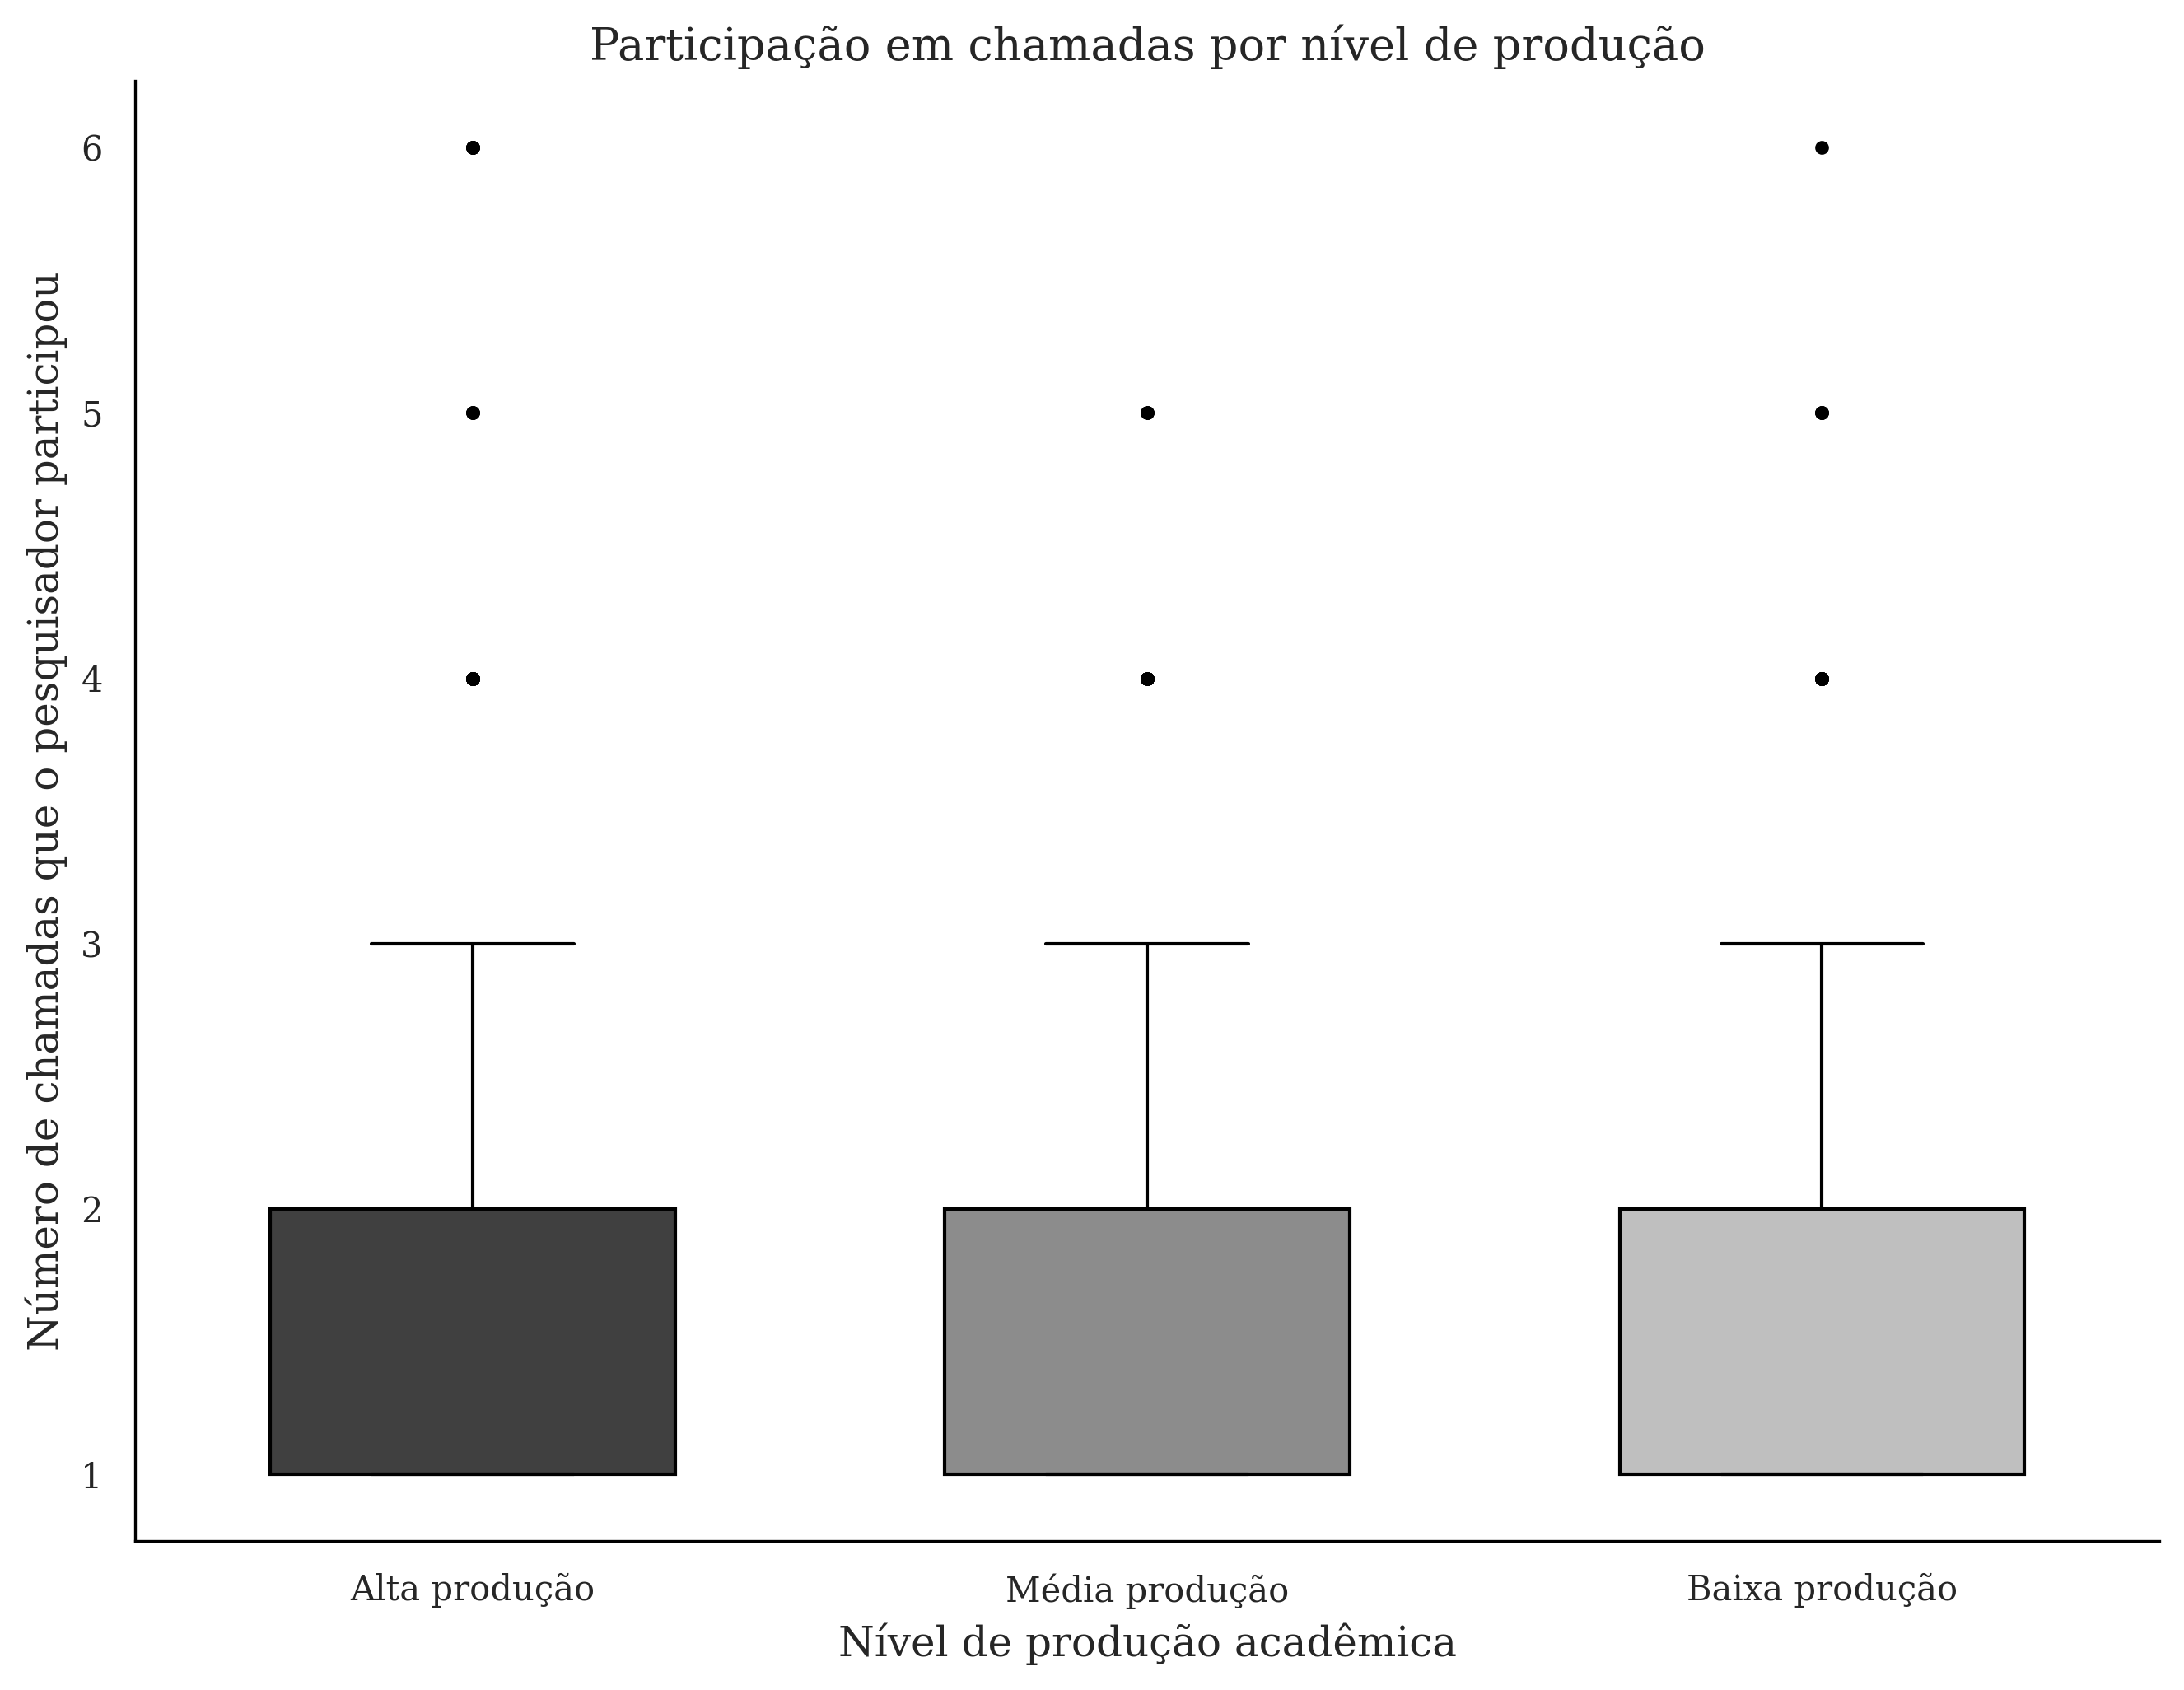

Gerando: fig4_PT_color.png


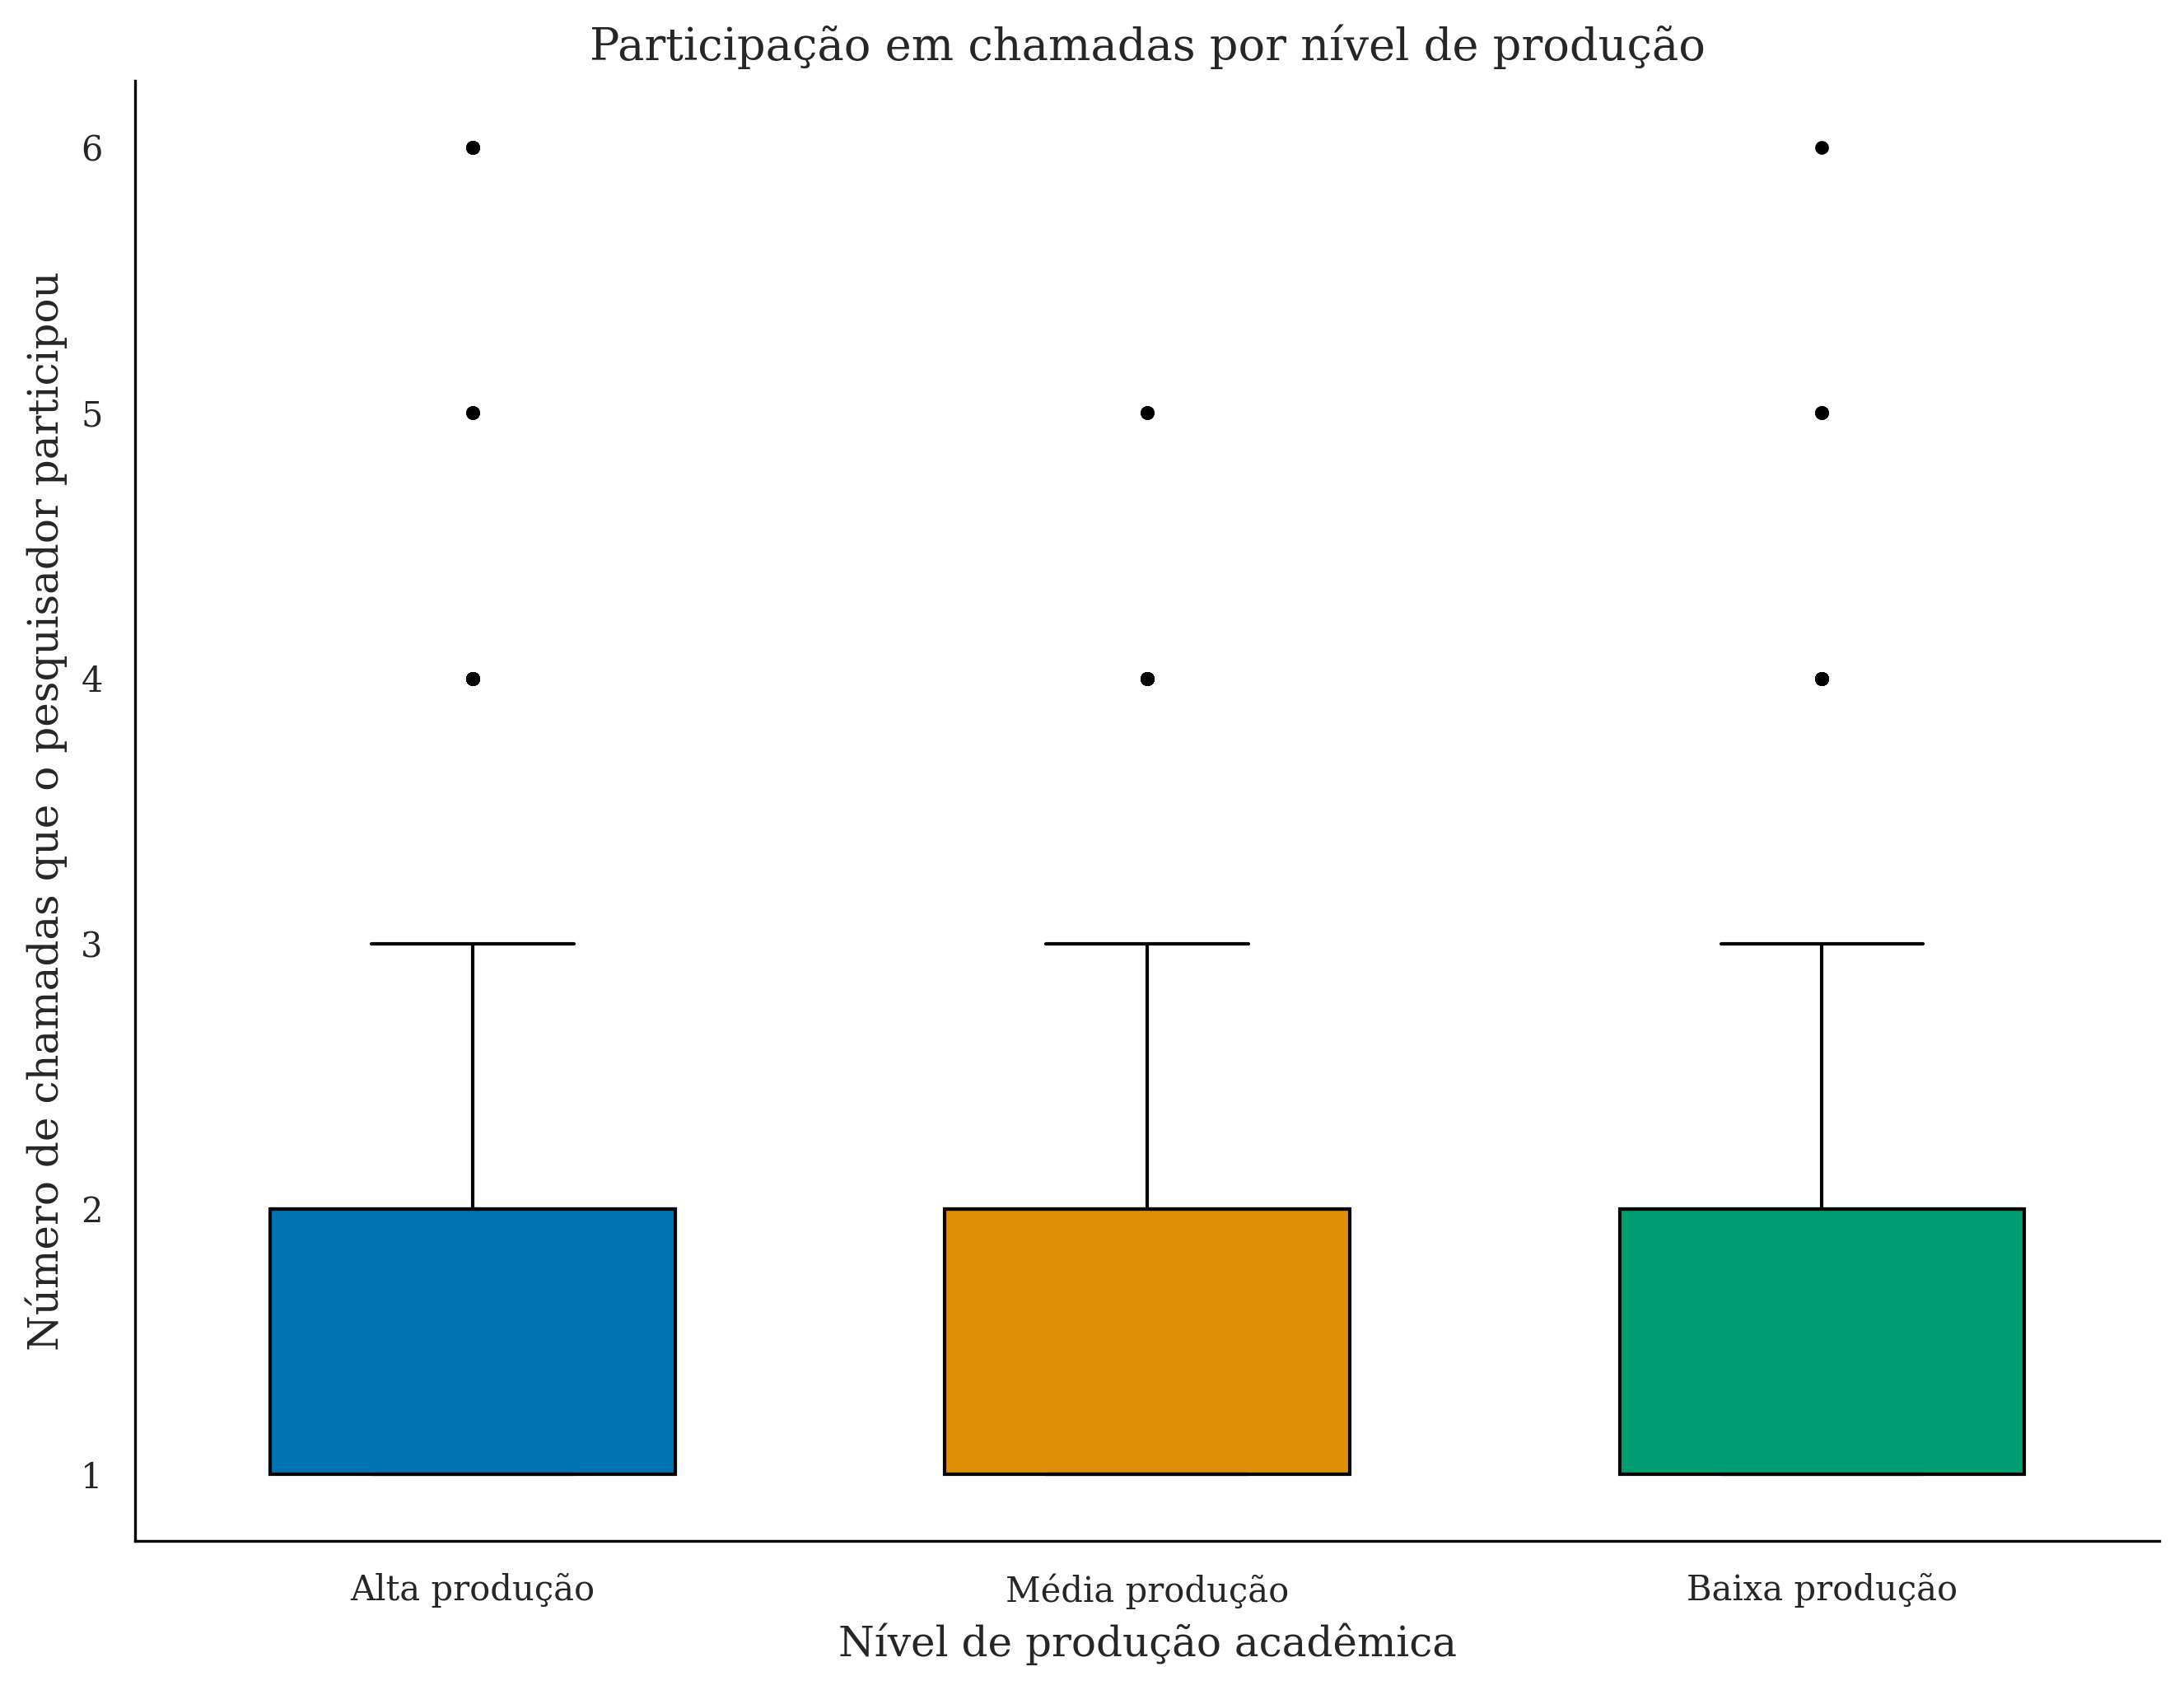

Gerando: fig4_EN_gray.png


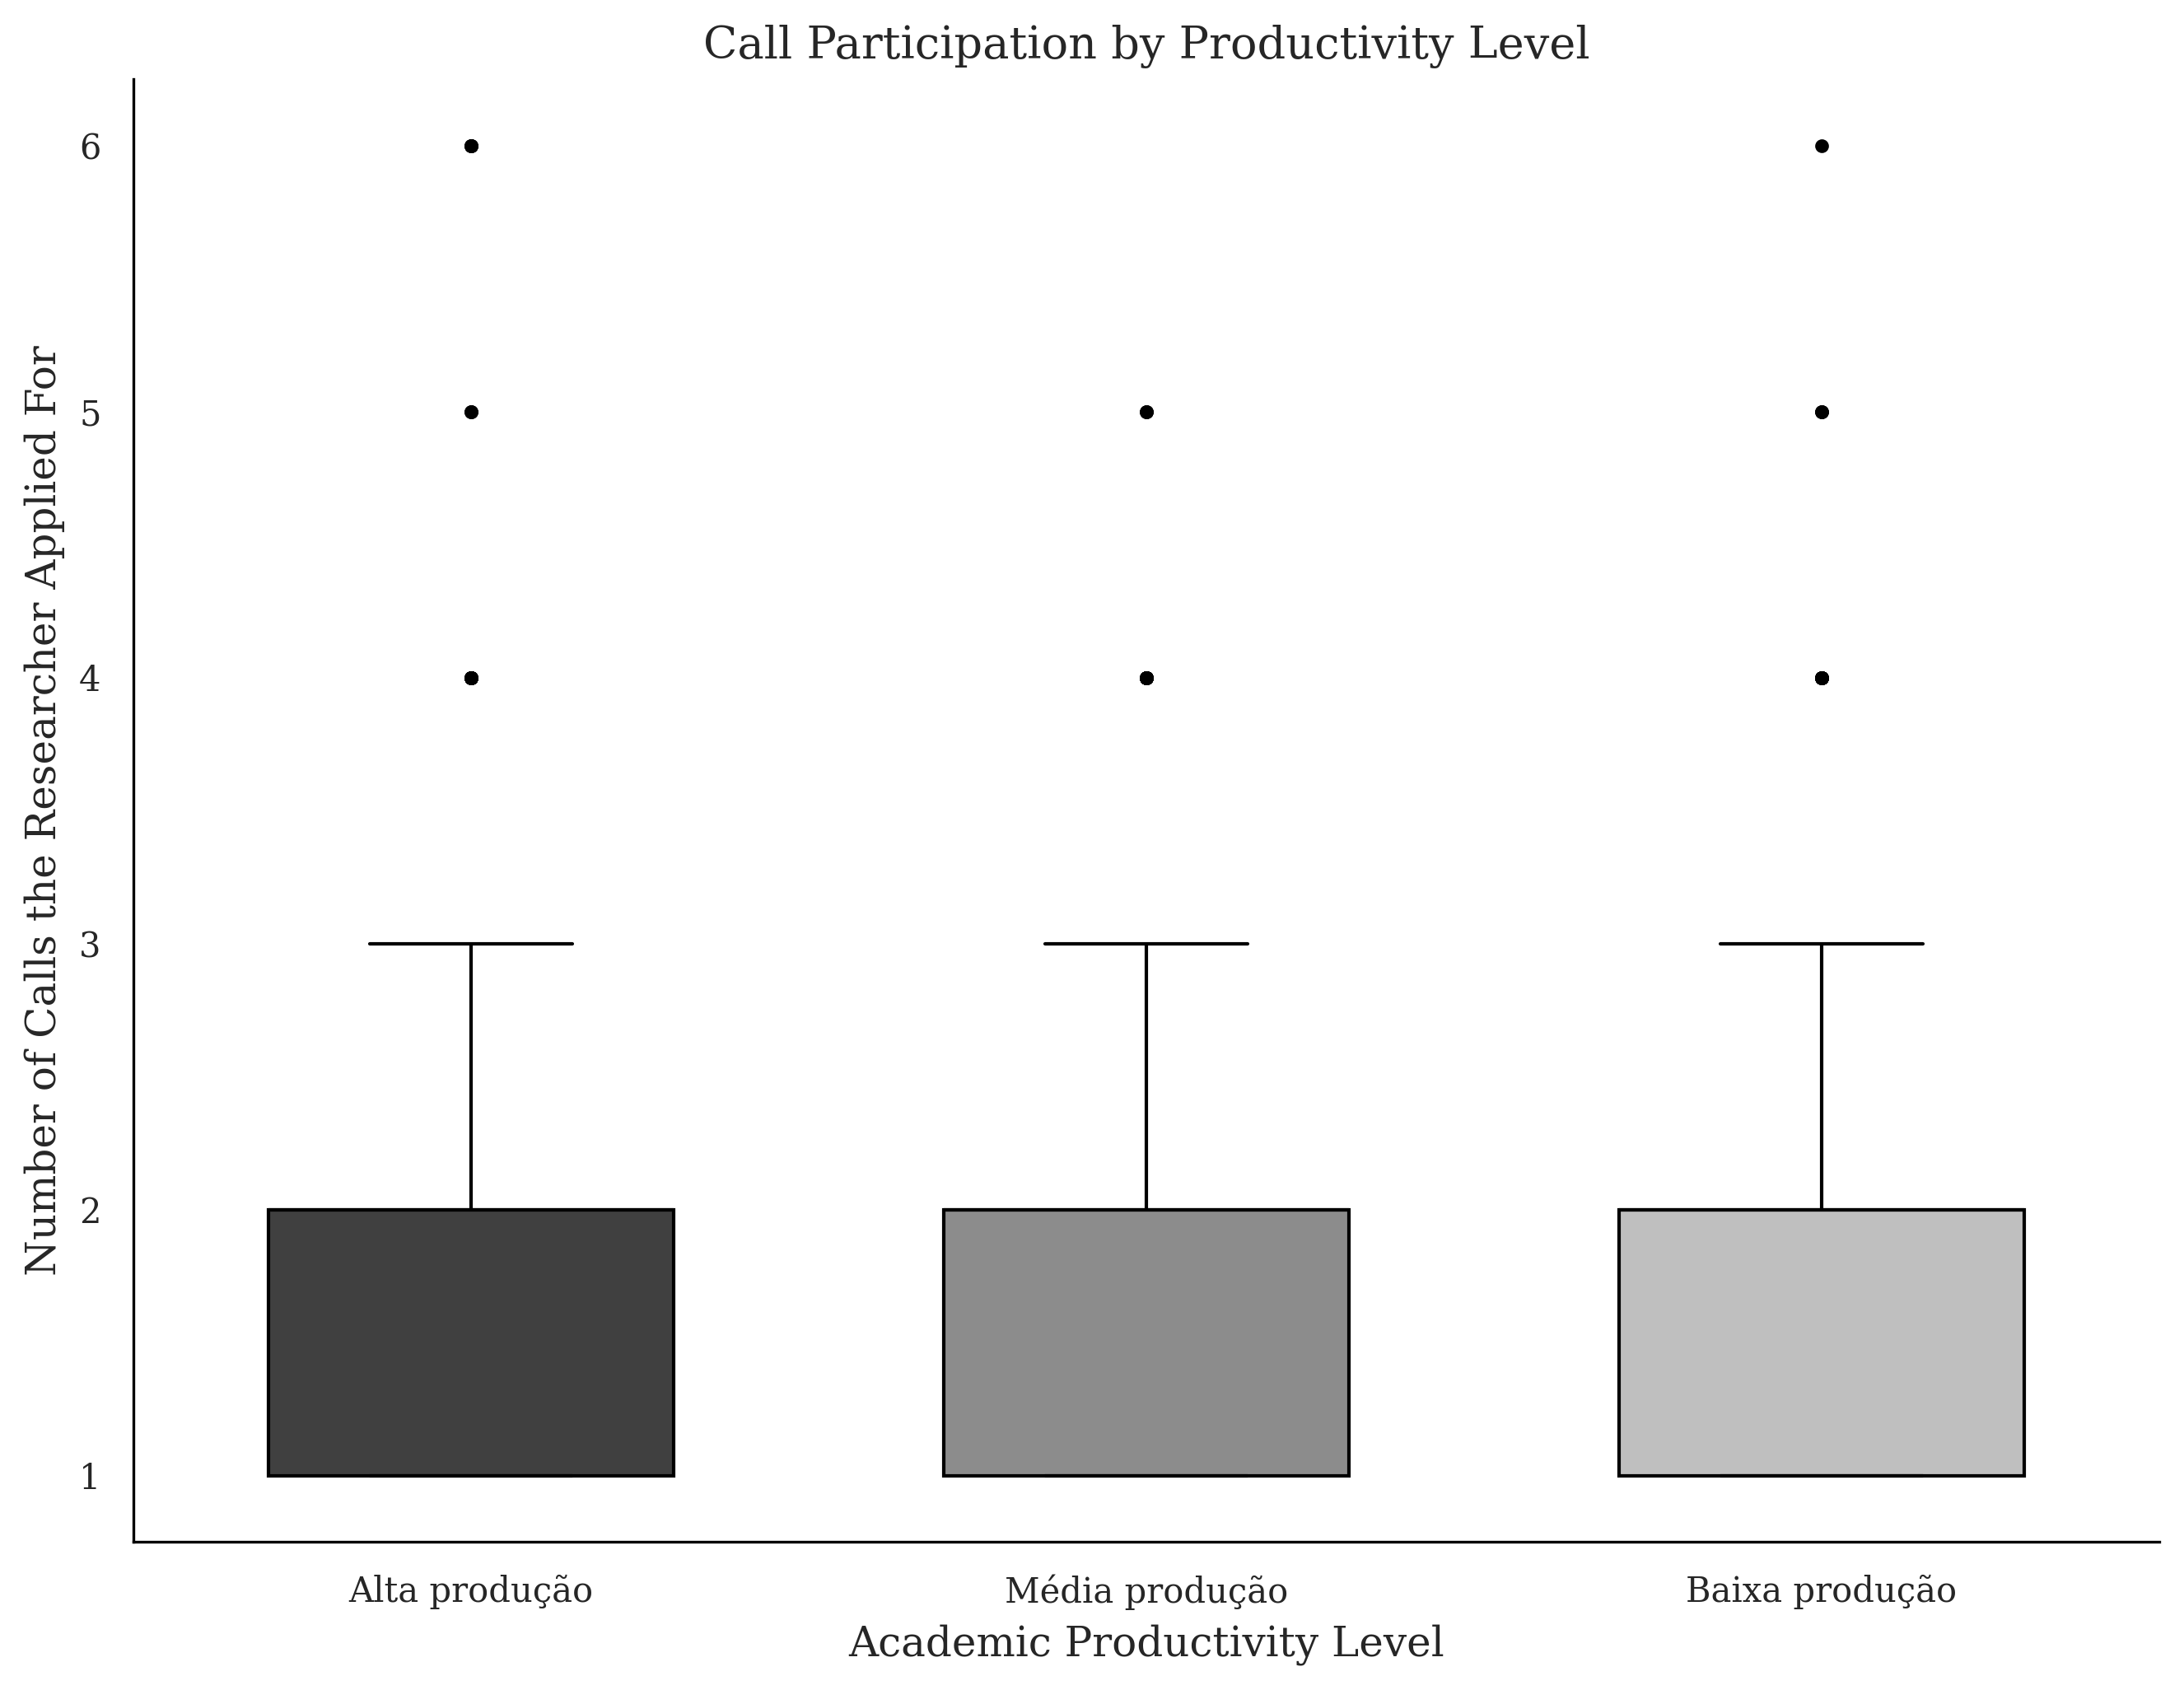

Gerando: fig4_EN_color.png


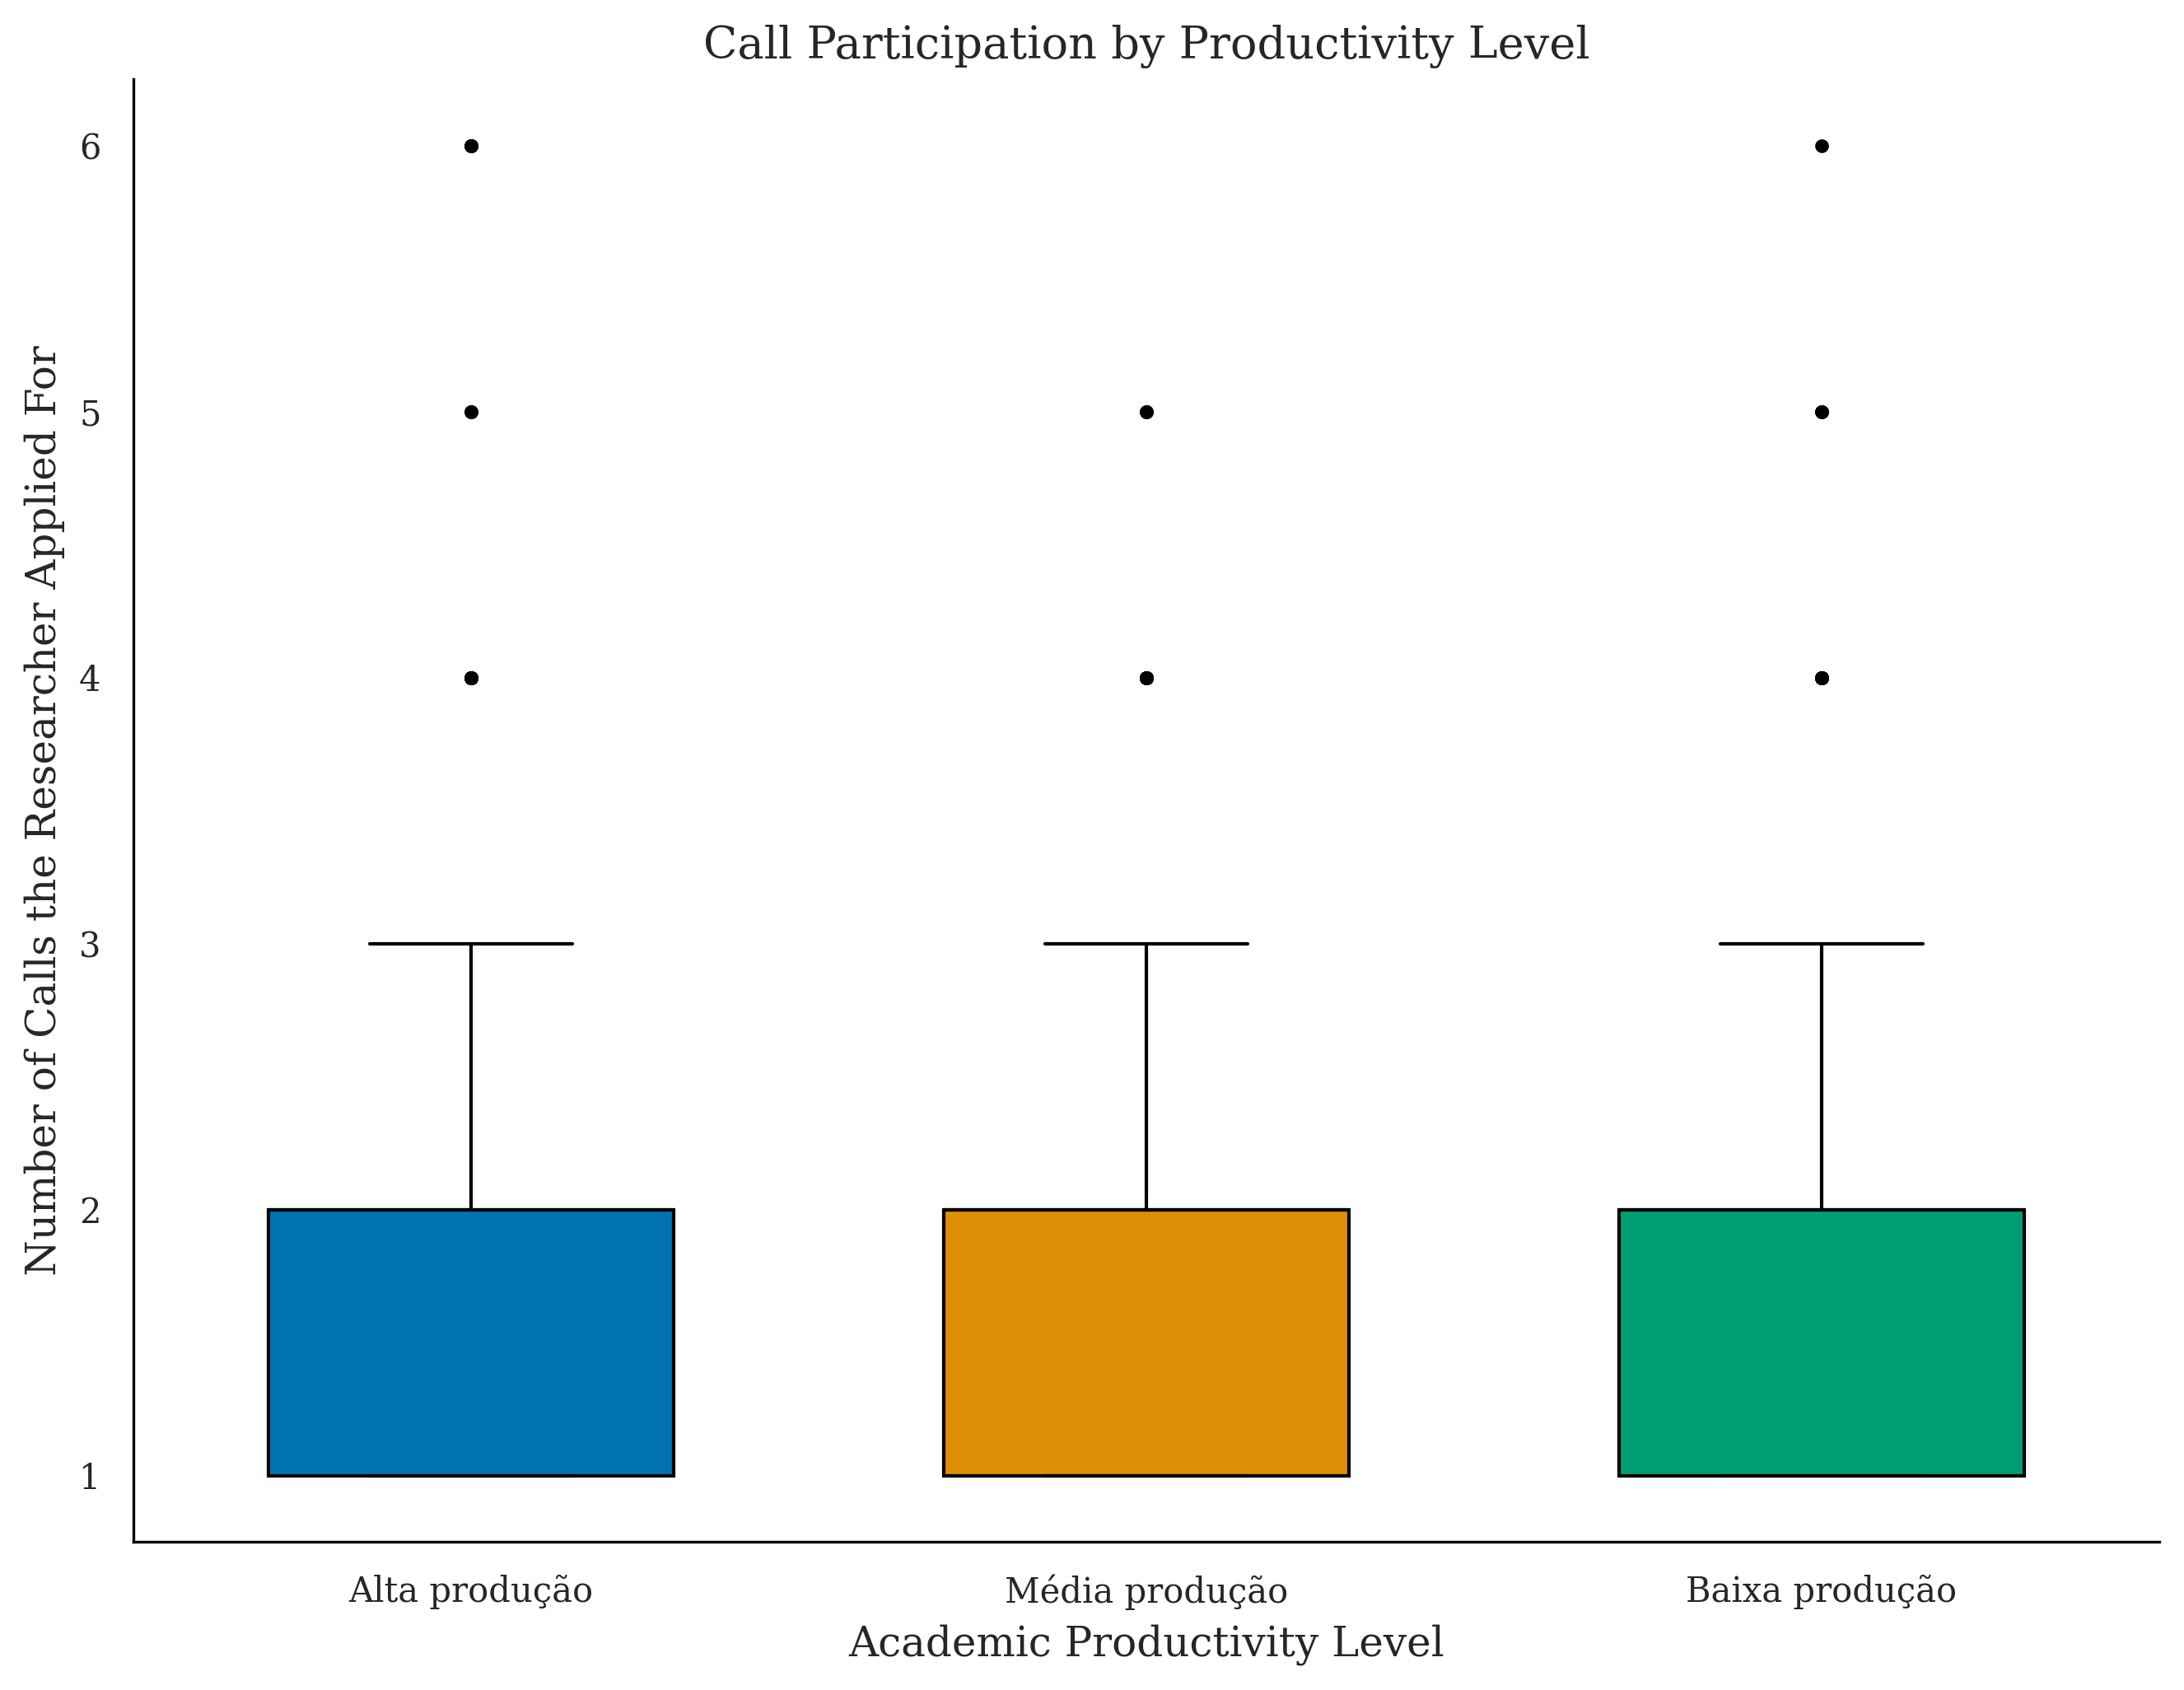


✔️ Todas as 4 versões corrigidas do Gráfico 4 foram geradas com sucesso!



In [15]:
# ===============================================================
# GRÁFICO 4 – Boxplot corrigido (sem o bug do Seaborn)
# PT/EN × cinza/colorido
# ===============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

def estilo_apa():
    mpl.rcParams.update({
        "font.family": "DejaVu Serif",
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 300
    })

# ordem correta
ordem_producao = ["Alta produção", "Média produção", "Baixa produção"]

# paletas
paleta_cinza = ["0.25", "0.55", "0.75"]
paleta_color = sns.color_palette("colorblind", 3)


def gerar_grafico4(idioma="pt", palette="gray"):
    estilo_apa()

    fig, ax = plt.subplots(figsize=(9, 7), dpi=300)

    # idioma
    if idioma == "pt":
        xlabel = "Nível de produção acadêmica"
        ylabel = "Número de chamadas que o pesquisador participou"
        titulo = "Participação em chamadas por nível de produção"
        ordem_plot = ordem_producao
    else:
        xlabel = "Academic Productivity Level"
        ylabel = "Number of Calls the Researcher Applied For"
        titulo = "Call Participation by Productivity Level"
        ordem_plot = ["Alta produção", "Média produção", "Baixa produção"]  # mantém original no eixo

    # cores
    cores = paleta_cinza if palette == "gray" else paleta_color

    # =====================================================
    # PLOT CORRIGIDO – gerando boxplots manualmente por categoria
    # =====================================================
    for i, categoria in enumerate(ordem_plot):
        valores = df.loc[df["nivel_producao_3grupos"] == categoria, "num_chamadas_participou"]

        ax.boxplot(
            valores,
            positions=[i],
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor=cores[i], color="black"),
            medianprops=dict(color="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", markersize=3, markerfacecolor="black", markeredgecolor="black")
        )

    ax.set_xticks(range(len(ordem_plot)))
    ax.set_xticklabels(ordem_plot)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(titulo, fontsize=13)

    plt.tight_layout()
    plt.show()

    return fig


# ---------------------------------------------------------------
# Geração e salvamento das 4 versões
# ---------------------------------------------------------------

arquivos = {
    "PT_gray": ("fig4_PT_cinza.png", "pt", "gray"),
    "PT_color": ("fig4_PT_color.png", "pt", "color"),
    "EN_gray": ("fig4_EN_gray.png", "en", "gray"),
    "EN_color": ("fig4_EN_color.png", "en", "color"),
}

print("\nGerando versões corrigidas do Gráfico 4...\n")

for nome, (arquivo, idioma, paleta) in arquivos.items():
    print(f"Gerando: {arquivo}")
    fig = gerar_grafico4(idioma=idioma, palette=paleta)
    fig.savefig(arquivo, dpi=600, bbox_inches="tight")
    plt.close(fig)

print("\n✔️ Todas as 4 versões corrigidas do Gráfico 4 foram geradas com sucesso!\n")



## 9. Salvar figuras para uso em artigos, tese e apresentações

Ajuste o caminho abaixo para a pasta onde deseja armazenar as imagens.

In [16]:
pasta_saida = "/content/drive/MyDrive/PIBICEM/05_Tabelas_Graficos/"

# Exemplo: salvar o boxplot de chamadas por tipo de instituição
fig = plt.figure()
sns.boxplot(data=df,
            x="tipo_ies_corrigido",
            y="num_chamadas_participou",
            order=ordem_tipo)
plt.xticks(rotation=45, ha='right')
plt.title("Participação em chamadas por tipo de instituição")
plt.xlabel("Tipo de instituição (corrigido)")
plt.ylabel("Número de chamadas que o pesquisador participou")
plt.tight_layout()

caminho_fig = os.path.join(pasta_saida, "boxplot_chamadas_tipoIES.png")
fig.savefig(caminho_fig, dpi=300)
plt.close(fig)

print("Figura salva em:", caminho_fig)


NameError: name 'ordem_tipo' is not defined

<Figure size 2400x1500 with 0 Axes>

## 10. Registro da sessão de análise

Use esta célula para anotar, em texto livre, o que foi feito nesta sessão.

### Registro – (preencher data)

- Base utilizada: `PIBICEM_base_visualizacoes.csv` (exportada do Jamovi).
- Variáveis principais: `tipo_ies_corrigido`, `nivel_producao_3grupos`, `num_chamadas_participou`.
- Gráficos gerados:
  - Distribuição de pesquisadores por tipo de instituição.
  - Barras empilhadas (tipo de instituição × nível de produção).
  - Boxplot de participação em chamadas por tipo de instituição.
  - Boxplot de participação em chamadas por nível de produção.
- Figuras salvas na pasta especificada em `pasta_saida`.
